### This is a test run-through of the full unsupervised learning pipeline

### This test run is all done on labeled variable stars so that we can get a better idea of how we need to apply unsupervised learning to the entire fornax region detected by DP1

### Note: This code also includes calculations of summary statistics using the Forced Source on DiaObject catalog

### Necessary Imports

In [9]:
from astroquery.vizier import Vizier
from astropy.coordinates import SkyCoord
import astropy.units as units
import csv
import pandas as pd
import numpy as np

# for viz
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.lines import Line2D
import seaborn as sns

# sklearn imports
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# lsst pipelines
from lsst.rsp import get_tap_service

In [10]:
#get an instance of the TAP service and assert that it exists
service = get_tap_service("tap")
assert service is not None

**Get variable star catalog that we will be working with**

In [11]:
# load csv of classified variable stars
path = os.getcwd()
v_star_catalog_path = os.path.join(path, 'variable_star_all_feat.csv')

v_star_catalog = pd.read_csv(v_star_catalog_path)

pd.reset_option('display.max_rows')
pd.set_option('display.max_columns', None)
v_star_catalog

,diaObjectId,ra,dec,g_psfFluxMean,r_psfFluxMean,i_psfFluxMean,g_psfFluxSigma,r_psfFluxSigma,i_psfFluxSigma,g_psfFluxChi2,r_psfFluxChi2,i_psfFluxChi2,g_psfFluxStetsonJ,r_psfFluxStetsonJ,i_psfFluxStetsonJ,g_psfFluxMAD,r_psfFluxMAD,i_psfFluxMAD,g_psfFluxNdata,r_psfFluxNdata,i_psfFluxNdata,nDiaSources,Region,Class,otype,otype_flag,g_psfFluxPercentile95,r_psfFluxPercentile95,i_psfFluxPercentile95,g_psfFluxPercentile50,r_psfFluxPercentile50,i_psfFluxPercentile50,g_psfFluxPercentile05,r_psfFluxPercentile05,i_psfFluxPercentile05,g_psfFluxLinearSlope,r_psfFluxLinearSlope,i_psfFluxLinearSlope,g_psfFluxMaxSlope,r_psfFluxMaxSlope,i_psfFluxMaxSlope,g_psfFluxSkew,r_psfFluxSkew,i_psfFluxSkew,g_scienceFluxMean,r_scienceFluxMean,i_scienceFluxMean,g_scienceFluxSigma,r_scienceFluxSigma,i_scienceFluxSigma,gmag,rmag,imag,g_r,r_i,g_i,amp_g,amp_r,amp_i,g_red_chi2,r_red_chi2,i_red_chi2,g_psfFluxSigma_norm,r_psfFluxSigma_norm,i_psfFluxSigma_norm,r_psfFluxMAD_rel,g_psfFluxMAD_rel,i_psfFluxMAD_rel,g_scienceFluxSigma_norm,r_scienceFluxSigma_norm,i_scienceFluxSigma_norm,W_mag_r_ri,W_mag_gr,W_mag_i_ri,W_mag_gi
0,579583227887354659,7.277627,-72.453601,NaN,6659.355957,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,1.0,NaN,1,47,RRLyrae,RR*,True,NaN,6659.355957,NaN,NaN,6659.355957,NaN,NaN,6659.355957,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54098.902344,NaN,NaN,NaN,NaN,NaN,19.567029,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,579574706672238627,4.974821,-72.683373,2142.085449,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,1.0,NaN,NaN,1,47,RRLyrae,RR*,True,2142.085449,NaN,NaN,2142.085449,NaN,NaN,2142.085449,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39428.195312,NaN,NaN,NaN,NaN,NaN,19.910483,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,579574569233285135,6.011728,-72.654608,-2534.255615,NaN,-7.695698,NaN,NaN,7380.872768,5.176740e-13,NaN,254.26800,NaN,NaN,15.224242,0.0,NaN,5219.070000,1.0,NaN,2.0,3,47,RRLyrae,RR*,True,-2534.255371,NaN,4585.559766,-2534.255371,NaN,-111.599121,-2534.255371,NaN,-4808.757520,NaN,NaN,-868.516082,NaN,NaN,-8.683926e+02,NaN,NaN,NaN,29299.523438,NaN,47978.964844,NaN,NaN,8083.117155,20.232849,NaN,19.697373,NaN,NaN,0.535476,0.0,NaN,NaN,inf,NaN,254.268000,NaN,NaN,-959.090718,NaN,0.0,0.161275,NaN,NaN,0.168472,NaN,NaN,NaN,19.015177
3,579575187708576418,6.298868,-72.611684,7049.521484,NaN,2416.182129,NaN,NaN,NaN,0.000000e+00,NaN,0.00000,NaN,NaN,NaN,0.0,NaN,0.000000,1.0,NaN,1.0,2,47,RRLyrae,RR*,True,7049.521484,NaN,2416.182129,7049.521484,NaN,2416.182129,7049.521484,NaN,2416.182129,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52186.820312,NaN,50817.039062,NaN,NaN,NaN,19.606098,NaN,19.634977,NaN,NaN,-0.028879,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,19.671768
4,579575256428052817,5.980350,-72.590526,2554.464600,-6780.240234,-801.362061,NaN,2091.403995,5294.444401,0.000000e+00,36.384200,522.44600,NaN,4.992266,12.702006,0.0,1478.850000,4499.990000,1.0,2.0,4.0,7,47,RRLyrae,RR*,True,2554.464600,-5671.762036,4388.073193,2554.464600,-7002.723389,-603.957764,2554.464600,-8333.684741,-5389.621338,NaN,-589.070678,759.578197,NaN,-589.170293,1.353681e+06,NaN,NaN,0.01399,33321.984375,42114.656250,45757.542969,NaN,691.970277,5163.227435,20.093173,19.838917,19.748843,0.254256,0.090074,0.344330,0.0,2661.922705,-282.140698,NaN,36.384200,174.148667,NaN,-0.308456,-6.606807,0.052061,0.0,0.145805,NaN,0.016431,0.112839,19.474029,19.100303,19.264337,19.310167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
746,604072100616995077,40.407272,-34.255539,NaN,-2344.862061,1329.692993,NaN,299.926727,37.739925,NaN,9.630550,0.02401,NaN,0.422049,-0

**Sorting by diaObjectId to keep our catalogs consistent**

In [12]:
v_star_catalog.sort_values('diaObjectId', axis=0, ascending=True, inplace=True)

In [13]:
v_star_catalog

,diaObjectId,ra,dec,g_psfFluxMean,r_psfFluxMean,i_psfFluxMean,g_psfFluxSigma,r_psfFluxSigma,i_psfFluxSigma,g_psfFluxChi2,r_psfFluxChi2,i_psfFluxChi2,g_psfFluxStetsonJ,r_psfFluxStetsonJ,i_psfFluxStetsonJ,g_psfFluxMAD,r_psfFluxMAD,i_psfFluxMAD,g_psfFluxNdata,r_psfFluxNdata,i_psfFluxNdata,nDiaSources,Region,Class,otype,otype_flag,g_psfFluxPercentile95,r_psfFluxPercentile95,i_psfFluxPercentile95,g_psfFluxPercentile50,r_psfFluxPercentile50,i_psfFluxPercentile50,g_psfFluxPercentile05,r_psfFluxPercentile05,i_psfFluxPercentile05,g_psfFluxLinearSlope,r_psfFluxLinearSlope,i_psfFluxLinearSlope,g_psfFluxMaxSlope,r_psfFluxMaxSlope,i_psfFluxMaxSlope,g_psfFluxSkew,r_psfFluxSkew,i_psfFluxSkew,g_scienceFluxMean,r_scienceFluxMean,i_scienceFluxMean,g_scienceFluxSigma,r_scienceFluxSigma,i_scienceFluxSigma,gmag,rmag,imag,g_r,r_i,g_i,amp_g,amp_r,amp_i,g_red_chi2,r_red_chi2,i_red_chi2,g_psfFluxSigma_norm,r_psfFluxSigma_norm,i_psfFluxSigma_norm,r_psfFluxMAD_rel,g_psfFluxMAD_rel,i_psfFluxMAD_rel,g_scienceFluxSigma_norm,r_scienceFluxSigma_norm,i_scienceFluxSigma_norm,W_mag_r_ri,W_mag_gr,W_mag_i_ri,W_mag_gi
2,579574569233285135,6.011728,-72.654608,-2534.255615,NaN,-7.695698,NaN,NaN,7380.872768,5.176740e-13,NaN,254.2680,NaN,NaN,15.224242,0.00,NaN,5219.07,1.0,NaN,2.0,3,47,RRLyrae,RR*,True,-2534.255371,NaN,4585.559766,-2534.255371,NaN,-111.599121,-2534.255371,NaN,-4808.757520,NaN,NaN,-868.516082,NaN,NaN,-8.683926e+02,NaN,NaN,NaN,29299.523438,NaN,4.797896e+04,NaN,NaN,8083.117155,20.232849,NaN,19.697373,NaN,NaN,0.535476,0.000000,NaN,NaN,inf,NaN,254.2680,NaN,NaN,-959.090718,NaN,0.000000,0.161275,NaN,NaN,0.168472,NaN,NaN,NaN,19.015177
103,579574569233285165,5.816260,-72.665276,NaN,-18028.753906,-17704.904297,NaN,NaN,46160.700109,NaN,0.0000,1427.4300,NaN,NaN,20.857132,NaN,0.00,10028.90,NaN,1.0,3.0,4,47,LPV,LP*,True,NaN,-18028.753906,20310.397266,NaN,-18028.753906,-46708.199219,NaN,-18028.753906,-55734.176172,NaN,NaN,-7204.883642,NaN,NaN,4.572696e+06,NaN,NaN,1.640530,NaN,1.174468e+06,2.034284e+06,NaN,NaN,218137.681644,NaN,16.225397,15.628971,NaN,0.596426,NaN,NaN,0.000000,37705.422266,NaN,NaN,713.7150,NaN,NaN,-2.607227,0.000000,NaN,0.007309,NaN,NaN,0.107231,13.809274,NaN,12.420793,NaN
102,579574569233285281,5.754789,-72.679581,NaN,NaN,-184243.281250,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,1.0,1,47,LPV,LP*,True,NaN,NaN,-184243.281250,NaN,NaN,-184243.281250,NaN,NaN,-184243.281250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.912854e+06,NaN,NaN,NaN,NaN,NaN,15.239203,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100,579574637952761891,5.389880,-72.696395,NaN,NaN,18112.621094,NaN,NaN,9335.155362,NaN,NaN,17.1935,NaN,NaN,3.329511,NaN,NaN,6600.95,NaN,NaN,2.0,2,47,LPV,C*,True,NaN,NaN,23666.055225,NaN,NaN,17725.198730,NaN,NaN,11784.342236,NaN,NaN,-1196.422367,NaN,NaN,-1.196602e+03,NaN,NaN,NaN,NaN,NaN,2.826738e+06,NaN,NaN,17997.812125,NaN,NaN,15.271786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.1935,NaN,NaN,0.515395,NaN,NaN,0.003462,NaN,NaN,0.006367,NaN,NaN,NaN,NaN
99,579574637952761900,5.352515,-72.690451,NaN,NaN,-428992.281250,NaN,NaN,686998.680689,NaN,NaN,76828.7000,NaN,NaN,261.981467,NaN,NaN,485781.00,NaN,NaN,2.0,2,47,LPV,C*,True,NaN,NaN,64125.707812,NaN,NaN,-373077.585938,NaN,NaN,-810280.856250,NaN,NaN,-88051.215533,NaN,NaN,-8.806108e+04,NaN,NaN,NaN,NaN,NaN,2.419296e+06,NaN,NaN,813141.950831,NaN,NaN,15.440777,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76828.7000,NaN,NaN,-1.601424,NaN,NaN,0.297698,NaN,NaN,0.336107,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,630408084161822977,106.103964,-9.971365,6007.253418,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,1.0,NaN,NaN,2,Seagull,LPV,NaN,False,6007.253418,NaN,NaN,6007.253418,NaN,NaN,

**Drop all instances where there aren't any observations in g,r,i bands**

In [14]:
drop_indices = v_star_catalog[(v_star_catalog['g_psfFluxNdata'].isna()) & (v_star_catalog['r_psfFluxNdata'].isna()) & (v_star_catalog['i_psfFluxNdata'].isna())].index
v_star_catalog.drop(index=drop_indices, inplace=True)

In [15]:
v_star_catalog

,diaObjectId,ra,dec,g_psfFluxMean,r_psfFluxMean,i_psfFluxMean,g_psfFluxSigma,r_psfFluxSigma,i_psfFluxSigma,g_psfFluxChi2,r_psfFluxChi2,i_psfFluxChi2,g_psfFluxStetsonJ,r_psfFluxStetsonJ,i_psfFluxStetsonJ,g_psfFluxMAD,r_psfFluxMAD,i_psfFluxMAD,g_psfFluxNdata,r_psfFluxNdata,i_psfFluxNdata,nDiaSources,Region,Class,otype,otype_flag,g_psfFluxPercentile95,r_psfFluxPercentile95,i_psfFluxPercentile95,g_psfFluxPercentile50,r_psfFluxPercentile50,i_psfFluxPercentile50,g_psfFluxPercentile05,r_psfFluxPercentile05,i_psfFluxPercentile05,g_psfFluxLinearSlope,r_psfFluxLinearSlope,i_psfFluxLinearSlope,g_psfFluxMaxSlope,r_psfFluxMaxSlope,i_psfFluxMaxSlope,g_psfFluxSkew,r_psfFluxSkew,i_psfFluxSkew,g_scienceFluxMean,r_scienceFluxMean,i_scienceFluxMean,g_scienceFluxSigma,r_scienceFluxSigma,i_scienceFluxSigma,gmag,rmag,imag,g_r,r_i,g_i,amp_g,amp_r,amp_i,g_red_chi2,r_red_chi2,i_red_chi2,g_psfFluxSigma_norm,r_psfFluxSigma_norm,i_psfFluxSigma_norm,r_psfFluxMAD_rel,g_psfFluxMAD_rel,i_psfFluxMAD_rel,g_scienceFluxSigma_norm,r_scienceFluxSigma_norm,i_scienceFluxSigma_norm,W_mag_r_ri,W_mag_gr,W_mag_i_ri,W_mag_gi
2,579574569233285135,6.011728,-72.654608,-2534.255615,NaN,-7.695698,NaN,NaN,7380.872768,5.176740e-13,NaN,254.2680,NaN,NaN,15.224242,0.00,NaN,5219.07,1.0,NaN,2.0,3,47,RRLyrae,RR*,True,-2534.255371,NaN,4585.559766,-2534.255371,NaN,-111.599121,-2534.255371,NaN,-4808.757520,NaN,NaN,-868.516082,NaN,NaN,-8.683926e+02,NaN,NaN,NaN,29299.523438,NaN,4.797896e+04,NaN,NaN,8083.117155,20.232849,NaN,19.697373,NaN,NaN,0.535476,0.000000,NaN,NaN,inf,NaN,254.2680,NaN,NaN,-959.090718,NaN,0.000000,0.161275,NaN,NaN,0.168472,NaN,NaN,NaN,19.015177
103,579574569233285165,5.816260,-72.665276,NaN,-18028.753906,-17704.904297,NaN,NaN,46160.700109,NaN,0.0000,1427.4300,NaN,NaN,20.857132,NaN,0.00,10028.90,NaN,1.0,3.0,4,47,LPV,LP*,True,NaN,-18028.753906,20310.397266,NaN,-18028.753906,-46708.199219,NaN,-18028.753906,-55734.176172,NaN,NaN,-7204.883642,NaN,NaN,4.572696e+06,NaN,NaN,1.640530,NaN,1.174468e+06,2.034284e+06,NaN,NaN,218137.681644,NaN,16.225397,15.628971,NaN,0.596426,NaN,NaN,0.000000,37705.422266,NaN,NaN,713.7150,NaN,NaN,-2.607227,0.000000,NaN,0.007309,NaN,NaN,0.107231,13.809274,NaN,12.420793,NaN
102,579574569233285281,5.754789,-72.679581,NaN,NaN,-184243.281250,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,1.0,1,47,LPV,LP*,True,NaN,NaN,-184243.281250,NaN,NaN,-184243.281250,NaN,NaN,-184243.281250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.912854e+06,NaN,NaN,NaN,NaN,NaN,15.239203,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100,579574637952761891,5.389880,-72.696395,NaN,NaN,18112.621094,NaN,NaN,9335.155362,NaN,NaN,17.1935,NaN,NaN,3.329511,NaN,NaN,6600.95,NaN,NaN,2.0,2,47,LPV,C*,True,NaN,NaN,23666.055225,NaN,NaN,17725.198730,NaN,NaN,11784.342236,NaN,NaN,-1196.422367,NaN,NaN,-1.196602e+03,NaN,NaN,NaN,NaN,NaN,2.826738e+06,NaN,NaN,17997.812125,NaN,NaN,15.271786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.1935,NaN,NaN,0.515395,NaN,NaN,0.003462,NaN,NaN,0.006367,NaN,NaN,NaN,NaN
99,579574637952761900,5.352515,-72.690451,NaN,NaN,-428992.281250,NaN,NaN,686998.680689,NaN,NaN,76828.7000,NaN,NaN,261.981467,NaN,NaN,485781.00,NaN,NaN,2.0,2,47,LPV,C*,True,NaN,NaN,64125.707812,NaN,NaN,-373077.585938,NaN,NaN,-810280.856250,NaN,NaN,-88051.215533,NaN,NaN,-8.806108e+04,NaN,NaN,NaN,NaN,NaN,2.419296e+06,NaN,NaN,813141.950831,NaN,NaN,15.440777,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76828.7000,NaN,NaN,-1.601424,NaN,NaN,0.297698,NaN,NaN,0.336107,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266,630408015442346205,106.282354,-9.946996,NaN,28141.541016,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,1.0,NaN,2,Seagull,LPV,NaN,False,NaN,28141.541016,NaN,NaN,28141.541016,NaN,NaN

**grab all objects with at least 4 observations in r band and at least 4 in the i-band and have acceptable stetsonJ (>2)**

In [16]:
v_star_catalog_subset = v_star_catalog[(v_star_catalog['r_psfFluxNdata'] > 3) & (v_star_catalog['i_psfFluxNdata'] > 3) & (v_star_catalog['r_psfFluxStetsonJ'] > 2) & (v_star_catalog['i_psfFluxStetsonJ'] > 2)]

In [17]:
v_star_catalog_subset

,diaObjectId,ra,dec,g_psfFluxMean,r_psfFluxMean,i_psfFluxMean,g_psfFluxSigma,r_psfFluxSigma,i_psfFluxSigma,g_psfFluxChi2,r_psfFluxChi2,i_psfFluxChi2,g_psfFluxStetsonJ,r_psfFluxStetsonJ,i_psfFluxStetsonJ,g_psfFluxMAD,r_psfFluxMAD,i_psfFluxMAD,g_psfFluxNdata,r_psfFluxNdata,i_psfFluxNdata,nDiaSources,Region,Class,otype,otype_flag,g_psfFluxPercentile95,r_psfFluxPercentile95,i_psfFluxPercentile95,g_psfFluxPercentile50,r_psfFluxPercentile50,i_psfFluxPercentile50,g_psfFluxPercentile05,r_psfFluxPercentile05,i_psfFluxPercentile05,g_psfFluxLinearSlope,r_psfFluxLinearSlope,i_psfFluxLinearSlope,g_psfFluxMaxSlope,r_psfFluxMaxSlope,i_psfFluxMaxSlope,g_psfFluxSkew,r_psfFluxSkew,i_psfFluxSkew,g_scienceFluxMean,r_scienceFluxMean,i_scienceFluxMean,g_scienceFluxSigma,r_scienceFluxSigma,i_scienceFluxSigma,gmag,rmag,imag,g_r,r_i,g_i,amp_g,amp_r,amp_i,g_red_chi2,r_red_chi2,i_red_chi2,g_psfFluxSigma_norm,r_psfFluxSigma_norm,i_psfFluxSigma_norm,r_psfFluxMAD_rel,g_psfFluxMAD_rel,i_psfFluxMAD_rel,g_scienceFluxSigma_norm,r_scienceFluxSigma_norm,i_scienceFluxSigma_norm,W_mag_r_ri,W_mag_gr,W_mag_i_ri,W_mag_gi
6,579575256428052608,6.131206,-72.535870,3551.469238,2256.967773,-683.594910,NaN,20084.917872,15072.810519,0.000,2.389660e+04,3197.090,NaN,43.766055,21.391475,0.00,7401.710000,1991.170000,1.0,10.0,4.0,15,47,RRLyrae,RR*,True,3551.469238,38994.763281,19067.249121,3551.469238,-5791.553955,-6033.679688,3551.469238,-13202.357617,-8.143472e+03,NaN,-2118.933673,-2688.534241,NaN,3.390524e+06,1.824429e+06,NaN,1.306770,1.916990,4.869991e+04,7.111567e+04,6.026722e+04,NaN,20358.782126,3.014476e+04,19.681180,19.270087,19.449797,0.411093,-0.179710,0.231382,0.000000,52197.120898,4.713824e+04,NaN,2655.177778,1065.696667,NaN,8.899072,-22.049331,0.154309,0.000000,0.048984,NaN,0.286277,0.500185,19.998094,18.075862,20.416459,19.155016
7,579575256428052935,5.749370,-72.562515,-2458.857910,-3932.516113,-4707.509277,33713.217524,15083.356053,19146.177524,9085.750,1.270890e+04,5545.660,91.219314,33.282176,24.862708,23838.80,6484.890000,1207.250000,2.0,8.0,4.0,14,47,RRLyrae,RR*,True,20898.193750,21044.452930,4280.432800,-556.765625,-8482.533936,2385.933716,-22011.726953,-15661.032666,-2.952734e+04,7.927920e+03,2113.773047,3448.378869,7.930342e+03,4.964968e+06,1.101634e+06,NaN,1.102430,-1.981840,6.115027e+04,5.442401e+04,5.404693e+04,33382.845358,15685.787582,1.929780e+04,19.434004,19.560524,19.568073,-0.126520,-0.007549,-0.134068,42909.920703,36705.485596,5.057180e+04,9085.750000,1815.557143,1848.553333,-13.710925,-3.835548,-4.067157,0.176659,0.577976,0.033117,0.545915,0.288214,0.357056,19.591104,19.928063,19.608678,19.738876
106,579575874903343117,6.730359,-72.358639,-25.737883,3627.943604,-583262.000000,7733.724286,33785.145143,704650.548858,355.715,9.200210e+03,1025240.000,8.063141,24.969751,342.031026,5039.19,28782.900000,43974.300000,4.0,14.0,8.0,29,47,LPV,LP*,True,8073.840479,46491.141797,225838.892187,54.088318,-1093.888672,181613.757812,-8206.885254,-34483.837891,-1.292955e+06,5.908120e+06,5858.651625,-119714.402184,2.093234e+07,2.398981e+07,1.190241e+09,-0.054288,0.062184,-0.771427,4.457930e+05,1.511268e+06,1.385747e+06,4561.662422,191619.667463,1.244062e+06,17.277167,15.951646,16.045790,1.325521,-0.094144,1.231377,16280.725732,80974.979688,1.339447e+06,118.571667,707.708462,146462.857143,-300.480207,9.312478,-1.208120,0.028237,0.016759,0.047048,0.010233,0.126794,0.897756,16.333022,12.101008,16.552189,14.477015
12,579575874903343152,6.735633,-72.369004,2046.855835,2359.760986,-824.211243,8023.468988,9615.826284,8010.566285,2664.470,1.874830e+04,2657.170,21.398342,24.317180,16.562392,6810.01,10337.400000,4112.860000,6.0,24.0,8.0,38,47,RRLyrae,RR*,True,11092.827881,19647.783496,6855.244800,3183.242676,3933.820312,2699.785889,-5196.752625,-6870.791040,-1.023185e+04,-2.400811e+03,1327.319052,1058.299245,6.038116e+06,4.040083e+06,1.119007e+06,-0.024169,0.279946,-0.485192,5.957411e+04,5.981317e+04,5.766799e+04,8212.743396,10230.450087,1.177007e+04,19.462356,19.458008,19.4

**Creating a test subset with only fornax values with acceptable reduced chi squared values (>2)**

In [18]:
v_star_catalog_subset[(v_star_catalog_subset['r_red_chi2'] > 2) & (v_star_catalog_subset['i_red_chi2'] > 2) & (v_star_catalog_subset['Region'] == 'Fornax')]

,diaObjectId,ra,dec,g_psfFluxMean,r_psfFluxMean,i_psfFluxMean,g_psfFluxSigma,r_psfFluxSigma,i_psfFluxSigma,g_psfFluxChi2,r_psfFluxChi2,i_psfFluxChi2,g_psfFluxStetsonJ,r_psfFluxStetsonJ,i_psfFluxStetsonJ,g_psfFluxMAD,r_psfFluxMAD,i_psfFluxMAD,g_psfFluxNdata,r_psfFluxNdata,i_psfFluxNdata,nDiaSources,Region,Class,otype,otype_flag,g_psfFluxPercentile95,r_psfFluxPercentile95,i_psfFluxPercentile95,g_psfFluxPercentile50,r_psfFluxPercentile50,i_psfFluxPercentile50,g_psfFluxPercentile05,r_psfFluxPercentile05,i_psfFluxPercentile05,g_psfFluxLinearSlope,r_psfFluxLinearSlope,i_psfFluxLinearSlope,g_psfFluxMaxSlope,r_psfFluxMaxSlope,i_psfFluxMaxSlope,g_psfFluxSkew,r_psfFluxSkew,i_psfFluxSkew,g_scienceFluxMean,r_scienceFluxMean,i_scienceFluxMean,g_scienceFluxSigma,r_scienceFluxSigma,i_scienceFluxSigma,gmag,rmag,imag,g_r,r_i,g_i,amp_g,amp_r,amp_i,g_red_chi2,r_red_chi2,i_red_chi2,g_psfFluxSigma_norm,r_psfFluxSigma_norm,i_psfFluxSigma_norm,r_psfFluxMAD_rel,g_psfFluxMAD_rel,i_psfFluxMAD_rel,g_scienceFluxSigma_norm,r_scienceFluxSigma_norm,i_scienceFluxSigma_norm,W_mag_r_ri,W_mag_gr,W_mag_i_ri,W_mag_gi
408,604061998853914685,40.027299,-34.799021,NaN,3795.996094,-187.533997,NaN,3919.731689,2275.420521,NaN,2393.659912,736.849976,NaN,15.697990,9.029769,NaN,278.152008,280.760986,NaN,6.0,9.0,15,Fornax,RRLyrae,RR*,True,NaN,6891.881836,2358.376611,NaN,6481.437500,2091.272949,NaN,-982.910919,-2459.149023,NaN,693.197220,389.918169,NaN,3.259987e+04,6.026719e+05,NaN,-0.955899,-0.365436,NaN,11915.249023,10665.728516,NaN,4144.379332,2624.905191,NaN,21.209742,21.330024,NaN,-0.120281,NaN,NaN,7874.792755,9351.030859,NaN,478.731982,92.106247,NaN,1.032596,-12.133376,0.034610,NaN,0.039027,NaN,0.347821,0.246107,21.697003,NaN,21.977018,NaN
228,604062067573391418,39.949663,-34.824183,-1202.112183,5333.978516,5613.262207,NaN,6288.538165,17818.882737,0.000000e+00,1517.760000,2667.740000,NaN,7.778627,17.987448,0.000,2377.090000,7257.840000,1.0,9.0,6.0,16,Fornax,LPV,NaN,False,-1202.112183,16979.446875,33360.832520,-1202.112183,6111.807129,731.739014,-1202.112183,619.795532,-7359.051514,NaN,-817.657192,-2864.279299,NaN,2.276223e+07,1.779564e+07,NaN,1.497850,1.292990,38516.507812,226293.265625,398310.156250,NaN,64504.023300,100457.629096,19.935883,18.013321,17.399447,1.922562,0.613874,2.536436,0.000000,16359.651343,24338.498389,NaN,189.720000,533.548000,NaN,1.178958,3.174426,0.015574,0.000000,0.027015,NaN,0.285046,0.252210,15.526516,12.428279,14.097416,14.168027
236,604062067573391439,40.011293,-34.807165,NaN,2707.102295,5147.237793,NaN,6008.067147,14101.636844,NaN,1667.360000,2521.870000,NaN,11.042984,10.797963,NaN,4649.660000,3093.440000,NaN,10.0,8.0,18,Fornax,LPV,C*,True,NaN,13807.006348,16990.186230,NaN,4788.460938,7318.120117,NaN,-1538.998029,-16996.405078,NaN,1124.171436,279.509116,NaN,1.825367e+07,6.979911e+06,NaN,0.758139,-2.167500,NaN,165754.140625,367744.343750,NaN,70181.307337,65333.238539,NaN,18.351339,17.486135,NaN,0.865204,NaN,NaN,15346.004376,30803.411426,NaN,185.262222,360.267143,NaN,2.219372,2.739651,0.041589,NaN,0.012472,NaN,0.423406,0.177659,14.846397,NaN,12.832202,NaN
209,604062067573391466,39.815931,-34.805787,1636.975830,-1429.734619,-689.240173,921.500183,22928.320765,33509.163438,7.625150e+00,12793.300000,8182.860000,1.983619,32.505468,27.124824,651.599,11715.900000,6357.920000,2.0,10.0,7.0,19,Fornax,LPV,AB*,True,2203.796887,23597.175781,49260.365234,1617.357788,11766.768066,-11943.159180,1030.918628,-27587.681152,-35152.271680,398645.352384,-3984.805123,-4601.812533,-3.160375e+06,4.527736e+06,6.196739e+07,NaN,-0.377054,1.111930,81638.273438,330369.125000,493807.687500,3726.872582,30340.654741,155699.686366,19.120265,17.602501,17.166105,1.517764,0.436396,1.954160,1172.878259,51184.856934,58749.447461,7.62515,1421.477778,1363.810000,0.562928,-16.036767,-48.617543,0.052578,0.011833,0.019089,0.045651,0.091839,0.315304,15.834661,13.193397,14.818731,14.676505
580,604062136292868156,39.737657,-34.796967,1531.777466,4355.780762,-4610.837402,NaN,7943.889391,86

In [19]:
# check missing values:
pd.set_option('display.max_rows', None)
v_star_catalog_subset.isna().sum()

diaObjectId                  0
ra                           0
dec                          0
g_psfFluxMean              134
r_psfFluxMean                0
i_psfFluxMean                0
g_psfFluxSigma             162
r_psfFluxSigma               0
i_psfFluxSigma               0
g_psfFluxChi2              134
r_psfFluxChi2                0
i_psfFluxChi2                0
g_psfFluxStetsonJ          162
r_psfFluxStetsonJ            0
i_psfFluxStetsonJ            0
g_psfFluxMAD               134
r_psfFluxMAD                 0
i_psfFluxMAD                 0
g_psfFluxNdata             134
r_psfFluxNdata               0
i_psfFluxNdata               0
nDiaSources                  0
Region                       0
Class                        0
otype                       11
otype_flag                   0
g_psfFluxPercentile95      134
r_psfFluxPercentile95        0
i_psfFluxPercentile95        0
g_psfFluxPercentile50      134
r_psfFluxPercentile50        0
i_psfFluxPercentile50        0
g_psfFlu

**Get a list of all diaObjectId's within the above subset and query Forced Source On DiaObject to get all observations that are not flagged or highly erroneous**

In [20]:
id_list = v_star_catalog_subset['diaObjectId'].tolist()
id_list_str = ','.join(str(x) for x in id_list)

In [21]:
pd.reset_option('display.max_rows')

In [22]:
print(len(id_list))

216


In [23]:
query = f"""SELECT fsodo.diaObjectId, fsodo.band, fsodo.coord_ra, fsodo.coord_dec, fsodo.psfFlux, fsodo.psfFluxErr,
        fsodo.invalidPsfFlag, fsodo.psfFlux_flag, fsodo.pixelFlags_saturated, fsodo.pixelFlags_cr, fsodo.pixelFlags_bad, fsodo.pixelFlags_interpolated, fsodo.pixelFlags_suspect, fsodo.pixelFlags_edge, fsodo.pixelFlags_nodata,
        vis.expMidptMJD
        FROM dp1.ForcedSourceOnDiaObject AS fsodo
        JOIN dp1.Visit as vis 
        ON vis.visit = fsodo.visit
        WHERE fsodo.band IS NOT NULL
        AND fsodo.coord_ra IS NOT NULL
        AND fsodo.coord_dec IS NOT NULL
        AND fsodo.diaObjectId IN ({id_list_str})
        AND fsodo.invalidPsfFlag = 0
        AND fsodo.psfFlux_flag = 0
        AND fsodo.pixelFlags_saturated = 0
        AND fsodo.pixelFlags_cr = 0
        AND fsodo.pixelFlags_bad = 0
        AND fsodo.pixelFlags_interpolated = 0
        AND fsodo.pixelFlags_suspect = 0
        AND fsodo.pixelFlags_edge = 0
        AND fsodo.pixelFlags_nodata = 0
        AND fsodo.band IN ('g', 'r', 'i')
        AND fsodo.psfFluxErr < 0.1 * fsodo.psfFlux
        ORDER BY fsodo.diaObjectId ASC
        """


job = service.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()
assert job.phase == 'COMPLETED'
v_star_FSODO = job.fetch_result().to_table().to_pandas() #get results -> turn into table -> turn table into pandas dataframe
print(str(len(v_star_FSODO)))

Job phase is COMPLETED
7360


In [24]:
v_star_FSODO['diaObjectId'].nunique()

216

In [25]:
v_star_FSODO

,diaObjectId,band,coord_ra,coord_dec,psfFlux,psfFluxErr,invalidPsfFlag,psfFlux_flag,pixelFlags_saturated,pixelFlags_cr,pixelFlags_bad,pixelFlags_interpolated,pixelFlags_suspect,pixelFlags_edge,pixelFlags_nodata,expMidptMJD
0,579575256428052608,i,6.131206,-72.53587,68058.203125,407.316986,False,False,False,False,False,False,False,False,False,60651.079478
1,579575256428052608,r,6.131206,-72.53587,63407.800781,341.463989,False,False,False,False,False,False,False,False,False,60651.058332
2,579575256428052608,g,6.131206,-72.53587,48045.000000,290.365997,False,False,False,False,False,False,False,False,False,60651.075426
3,579575256428052608,r,6.131206,-72.53587,61364.601562,315.441010,False,False,False,False,False,False,False,False,False,60651.072455
4,579575256428052608,r,6.131206,-72.53587,61352.101562,341.735992,False,False,False,False,False,False,False,False,False,60651.072043
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7355,648375409829740567,i,38.601781,7.39352,763548.000000,956.388000,False,False,False,False,False,False,False,False,False,60638.138164
7356,648375409829740567,r,38.601781,7.39352,818701.000000,847.671997,False,False,False,False,False,False,False,False,False,60641.049749
7357,648375409829740567,r,38.601781,7.39352,847063.000000,894.362976,False,False,False,False,False,False,False,False,False,60641.047324
7358,648375409829740567,i,38.601781,7.39352,888970.000000,1011.840027,False,False,False,False,False,False,False,False,False,60641.078233


We now want to calculate reliable measurements for magnitude (from psfFlux), magnitude errors (from psfFlux and psfFluxError), and a weighted average that aggregates this measurement and is a reliable value for typical magnitude. We will create functions for these operations that we can perform on individual measurements

Following this formula for weighted mean (as indicated in our notes):

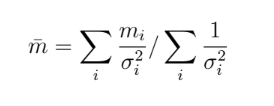

In [26]:
def fluxToABMagnitude(flux):
    return (-2.5 * np.log10(flux)) + 31.4

def getMagnitudeError(flux, flux_err):
    return (2.5 * np.log10(1 + (flux_err / flux)))

def getWeightedMean(mags, mag_errors):
    weights = 1 / (mag_errors**2)
    weighted_mean = np.sum(mags * weights) / np.sum(weights)

    return weighted_mean

In [27]:
# add columns for magnitudes and mag errors for each observation
v_star_FSODO['psfFluxMag'] = fluxToABMagnitude(v_star_FSODO['psfFlux'])
v_star_FSODO['psfFluxMagErr'] = getMagnitudeError(v_star_FSODO['psfFlux'], v_star_FSODO['psfFluxErr'])

In [28]:
v_star_FSODO

,diaObjectId,band,coord_ra,coord_dec,psfFlux,psfFluxErr,invalidPsfFlag,psfFlux_flag,pixelFlags_saturated,pixelFlags_cr,pixelFlags_bad,pixelFlags_interpolated,pixelFlags_suspect,pixelFlags_edge,pixelFlags_nodata,expMidptMJD,psfFluxMag,psfFluxMagErr
0,579575256428052608,i,6.131206,-72.53587,68058.203125,407.316986,False,False,False,False,False,False,False,False,False,60651.079478,19.317799,0.006479
1,579575256428052608,r,6.131206,-72.53587,63407.800781,341.463989,False,False,False,False,False,False,False,False,False,60651.058332,19.394642,0.005831
2,579575256428052608,g,6.131206,-72.53587,48045.000000,290.365997,False,False,False,False,False,False,False,False,False,60651.075426,19.695879,0.006542
3,579575256428052608,r,6.131206,-72.53587,61364.601562,315.441010,False,False,False,False,False,False,False,False,False,60651.072455,19.430204,0.005567
4,579575256428052608,r,6.131206,-72.53587,61352.101562,341.735992,False,False,False,False,False,False,False,False,False,60651.072043,19.430424,0.006031
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7355,648375409829740567,i,38.601781,7.39352,763548.000000,956.388000,False,False,False,False,False,False,False,False,False,60638.138164,16.692907,0.001359
7356,648375409829740567,r,38.601781,7.39352,818701.000000,847.671997,False,False,False,False,False,False,False,False,False,60641.049749,16.617186,0.001124
7357,648375409829740567,r,38.601781,7.39352,847063.000000,894.362976,False,False,False,False,False,False,False,False,False,60641.047324,16.580210,0.001146
7358,648375409829740567,i,38.601781,7.39352,888970.000000,1011.840027,False,False,False,False,False,False,False,False,False,60641.078233,16.527782,0.001235


In [29]:
# look at the distribution of magnitude errors (most should be ok)
v_star_FSODO['psfFluxMagErr'].describe()

count    7360.000000
mean        0.006935
std         0.008317
min         0.000671
25%         0.001781
50%         0.002619
75%         0.010126
max         0.099768
Name: psfFluxMagErr, dtype: float64

**Creating a new dataframe to hold above FSODO observations**

**This dataframe will be separated into groups based on diaObjectId and band. Within each group, we will sort by expMidptMJD (time) which will be helpful later when we want to see the amount of change between adjacent measurements (for calculating slope)**

In [30]:
v_star_FSODO_sorted = v_star_FSODO.groupby(['diaObjectId', 'band'], group_keys=False).apply(lambda group: group.sort_values('expMidptMJD'))

/tmp/ipykernel_24369/532855820.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v_star_FSODO_sorted = v_star_FSODO.groupby(['diaObjectId', 'band'], group_keys=False).apply(lambda group: group.sort_values('expMidptMJD'))


In [31]:
v_star_FSODO_sorted.head(20)

,diaObjectId,band,coord_ra,coord_dec,psfFlux,psfFluxErr,invalidPsfFlag,psfFlux_flag,pixelFlags_saturated,pixelFlags_cr,pixelFlags_bad,pixelFlags_interpolated,pixelFlags_suspect,pixelFlags_edge,pixelFlags_nodata,expMidptMJD,psfFluxMag,psfFluxMagErr
11,579575256428052608,g,6.131206,-72.535870,45212.898438,283.106995,False,False,False,False,False,False,False,False,False,60645.063366,19.761845,0.006777
2,579575256428052608,g,6.131206,-72.535870,48045.000000,290.365997,False,False,False,False,False,False,False,False,False,60651.075426,19.695879,0.006542
13,579575256428052608,i,6.131206,-72.535870,76819.101562,402.420990,False,False,False,False,False,False,False,False,False,60639.058816,19.186325,0.005673
15,579575256428052608,i,6.131206,-72.535870,77004.101562,402.110992,False,False,False,False,False,False,False,False,False,60639.059419,19.183714,0.005655
8,579575256428052608,i,6.131206,-72.535870,98602.000000,446.309998,False,False,False,False,False,False,False,False,False,60640.044046,18.915285,0.004903
7,579575256428052608,i,6.131206,-72.535870,68122.296875,396.666992,False,False,False,False,False,False,False,False,False,60651.076876,19.316776,0.006304
0,579575256428052608,i,6.131206,-72.535870,68058.203125,407.316986,False,False,False,False,False,False,False,False,False,60651.079478,19.317799,0.006479
9,579575256428052608,r,6.131206,-72.535870,72374.500000,296.170013,False,False,False,False,False,False,False,False,False,60639.051140,19.251036,0.004434
10,579575256428052608,r,6.131206,-72.535870,72197.101562,298.910004,False,False,False,False,False,False,False,False,False,60639.052964,19.253700,0.004486
5,579575256428052608,r,6.131206,-72.535870,108127.000000,378.893005,False,False,False,False,False,False,False,False,False,60640.039082,18.815163,0.003798


**Calculate slope by comparing adjacent observations' time and fluxes

In [32]:
# code to retrieve slope (delta psflux / delta time) for every pair of observations

# first assign default values
prev_diaObjectId = -1
prev_band = ''
prev_psfFluxMag = -1.0
prev_mjd = -1.0
for index,row in v_star_FSODO_sorted.iterrows():
    if (row['diaObjectId'] == prev_diaObjectId) and (row['band'] == prev_band):
        v_star_FSODO_sorted.loc[index, 'slope'] = np.abs((row['psfFluxMag'] - prev_psfFluxMag) / (row['expMidptMJD'] - prev_mjd))
    else:
        v_star_FSODO_sorted.loc[index, 'slope'] = None

    prev_diaObjectId = row['diaObjectId']
    prev_band = row['band']
    prev_psfFluxMag = row['psfFluxMag']
    prev_mjd = row['expMidptMJD']

In [33]:
v_star_FSODO_sorted.head()

,diaObjectId,band,coord_ra,coord_dec,psfFlux,psfFluxErr,invalidPsfFlag,psfFlux_flag,pixelFlags_saturated,pixelFlags_cr,pixelFlags_bad,pixelFlags_interpolated,pixelFlags_suspect,pixelFlags_edge,pixelFlags_nodata,expMidptMJD,psfFluxMag,psfFluxMagErr,slope
11,579575256428052608,g,6.131206,-72.53587,45212.898438,283.106995,False,False,False,False,False,False,False,False,False,60645.063366,19.761845,0.006777,None
2,579575256428052608,g,6.131206,-72.53587,48045.000000,290.365997,False,False,False,False,False,False,False,False,False,60651.075426,19.695879,0.006542,0.010972
13,579575256428052608,i,6.131206,-72.53587,76819.101562,402.420990,False,False,False,False,False,False,False,False,False,60639.058816,19.186325,0.005673,None
15,579575256428052608,i,6.131206,-72.53587,77004.101562,402.110992,False,False,False,False,False,False,False,False,False,60639.059419,19.183714,0.005655,4.330673
8,579575256428052608,i,6.131206,-72.53587,98602.000000,446.309998,False,False,False,False,False,False,False,False,False,60640.044046,18.915285,0.004903,0.27262


We now want to retrieve other summary statistics useful to us, now that we have converted everything into magnitude scale and gotten slopes between observations. These include:
- psfFluxMag weighted average
- psfFluxMagMin (brightest observed magnitude)
- psfFluxMagMax (faintest observed magnitude)
- psfFluxMag 95th and 5th percentile
- median
- max slope
- standard deviation - calculated from psfFluxMags -> will be used for a sigma norm
- median absolute deviation (MAD) - calculated from psfFluxMags -> might be more resistant to outliers
- chi2
- skew - calculated from psfFluxMags

**We will create a function to calculate reduced chi2 for us as well following this formula:**

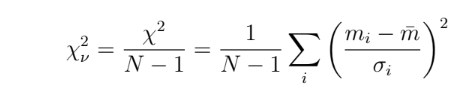

In [34]:
# define function to calculate reduced chi2
def getRedChi2 (mags, mag_errors):
    if len(mags) < 2 or np.any(mag_errors == 0):
        return np.nan  # Avoid divide by zero
    weighted_mean = getWeightedMean(mags, mag_errors)
    print(weighted_mean)
    chi2 = np.sum(((mags - weighted_mean) / mag_errors) ** 2)
    dof = len(mags) - 1
    return chi2 / dof # returns the reduced chi2

**Creating temporary dataframes to store weighted mean magnitude and reduced chi^2**

In [35]:
# grab the weighted average for psfFlux magnitudes and chi2 using groupby and apply and store in its own df (will merge after)
weightedMean_df = v_star_FSODO_sorted.groupby(['diaObjectId', 'band'])[['psfFluxMag', 'psfFluxMagErr']].apply(lambda group: pd.Series({'weightedMag': getWeightedMean(group['psfFluxMag'], group['psfFluxMagErr'])})).reset_index()
chi2_red_df = v_star_FSODO_sorted.groupby(['diaObjectId', 'band'])[['psfFluxMag', 'psfFluxMagErr']].apply(lambda group: pd.Series({'chi2_red': getRedChi2(group['psfFluxMag'], group['psfFluxMagErr'])})).reset_index()

19.727697
19.154024
19.188501
19.248844
19.173748
19.449638
17.352861
15.075785
15.888927
19.443024
19.361773
19.427704
19.464207
19.504198
19.424664
19.87252
19.756083
19.885082
18.03574
15.24005
16.124496
19.416477
19.37815
19.432554
17.150845
15.137462
15.658615
20.135696
19.456137
19.359247
19.681635
19.62694
19.594362
19.3281
19.042242
19.163113
17.389322
17.477518
17.571182
17.904997
15.696401
16.431845
20.017784
16.60153
17.79543
17.818678
15.634925
16.29106
19.576937
19.614115
19.628242
17.306345
15.496979
16.044933
19.616753
19.549335
19.724072
19.321476
19.219961
19.360138
20.199621
20.392067
20.021908
17.364668
15.501089
16.095942
20.00086
19.600733
19.620415
19.70391
19.548822
19.623112
19.592213
19.678509
19.670141
19.402824
19.18944
19.292702
19.775652
19.528244
19.654036
19.95764
19.791267
19.867935
19.149206
19.443657
19.421661
17.57218
15.359288
16.049099
15.615072
16.200363
19.272852
19.485197
19.47463
19.527763
19.412888
19.459421
19.149668
19.349342
19.441751
19.339

In [36]:
display(weightedMean_df)
display(chi2_red_df)

,diaObjectId,band,weightedMag
0,579575256428052608,g,19.727697
1,579575256428052608,i,19.154024
2,579575256428052608,r,19.188501
3,579575256428052935,g,19.248844
4,579575256428052935,i,19.173748
...,...,...,...
641,614436990573609020,i,15.934390
642,614436990573609020,r,15.924766
643,648375409829740567,g,17.255167
644,648375409829740567,i,16.660164


,diaObjectId,band,chi2_red
0,579575256428052608,g,49.041779
1,579575256428052608,i,934.055542
2,579575256428052608,r,3639.176270
3,579575256428052935,g,9763.630859
4,579575256428052935,i,866.255005
...,...,...,...
641,614436990573609020,i,15191.302734
642,614436990573609020,r,16749.216797
643,648375409829740567,g,15775.666992
644,648375409829740567,i,10117.209961


In [37]:
chi2_red_df['chi2_red'].describe()

count       625.000000
mean      14163.761285
std       54380.569770
min           0.083457
25%         119.087738
50%         471.802551
75%        1967.246460
max      600545.062500
Name: chi2_red, dtype: float64

**Merge the above two temporary dataframes into one for holding all values**

In [38]:
# merge the two on diaObjectID and band
fsodo_merged = pd.merge(weightedMean_df, chi2_red_df, on=['diaObjectId', 'band'], how='inner')

In [39]:
fsodo_merged

,diaObjectId,band,weightedMag,chi2_red
0,579575256428052608,g,19.727697,49.041779
1,579575256428052608,i,19.154024,934.055542
2,579575256428052608,r,19.188501,3639.176270
3,579575256428052935,g,19.248844,9763.630859
4,579575256428052935,i,19.173748,866.255005
...,...,...,...,...
641,614436990573609020,i,15.934390,15191.302734
642,614436990573609020,r,15.924766,16749.216797
643,648375409829740567,g,17.255167,15775.666992
644,648375409829740567,i,16.660164,10117.209961


**Convert to pivot table**

In [40]:
fsodo_merged = fsodo_merged.pivot(index='diaObjectId', columns='band', values=['weightedMag', 'chi2_red']).reset_index()

In [41]:
fsodo_merged

diaObjectId weightedMag                            chi2_red  \
band                               g          i          r             g   
0     579575256428052608   19.727697  19.154024  19.188501     49.041779   
1     579575256428052935   19.248844  19.173748  19.449638   9763.630859   
2     579575874903343117   17.352861  15.075785  15.888927   8436.857422   
3     579575874903343152   19.443024  19.361773  19.427704    569.564453   
4     579575874903343585   19.464207  19.504198  19.424664   3006.927246   
..                   ...         ...        ...        ...           ...   
211   605447108627005500   21.687540  21.141605  21.112034      1.061827   
212   605447795821772923   19.215321  17.333521  17.899797     33.865826   
213   614431011979133047   20.337189  20.148146  20.146133   1114.424194   
214   614436990573609020   15.980476  15.934390  15.924766  31356.613281   
215   648375409829740567   17.255167  16.660164  16.764706  15775.666992   

                                  
band             i             r  
0       934.055542   3639.176270  
1       866.255005   2253.916260  
2       308.657959  22134.060547  
3       372.372894    872.649353  
4       352.468018    883.977722  
..             ...           ...  
211     101.546577    101.439980  
212      20.938047     24.176254  
213     263.867889    644.709473  
214   15191.302734  16749.216797  
215   10117.209961  11373.844727  

[216 rows x 7 columns]

In [42]:
fsodo_merged.columns

MultiIndex([('diaObjectId',  ''),
            ('weightedMag', 'g'),
            ('weightedMag', 'i'),
            ('weightedMag', 'r'),
            (   'chi2_red', 'g'),
            (   'chi2_red', 'i'),
            (   'chi2_red', 'r')],
           names=[None, 'band'])

**Condense column names into one string each**

In [43]:
fsodo_merged.columns = ['{}_{}'.format(col[0], col[1]) for col in fsodo_merged.columns]
# fsodo_merged = fsodo_merged.reset_index()

In [44]:
fsodo_merged.rename(columns={'diaObjectId_': 'diaObjectId'}, inplace=True)

In [45]:
fsodo_merged

,diaObjectId,weightedMag_g,weightedMag_i,weightedMag_r,chi2_red_g,chi2_red_i,chi2_red_r
0,579575256428052608,19.727697,19.154024,19.188501,49.041779,934.055542,3639.176270
1,579575256428052935,19.248844,19.173748,19.449638,9763.630859,866.255005,2253.916260
2,579575874903343117,17.352861,15.075785,15.888927,8436.857422,308.657959,22134.060547
3,579575874903343152,19.443024,19.361773,19.427704,569.564453,372.372894,872.649353
4,579575874903343585,19.464207,19.504198,19.424664,3006.927246,352.468018,883.977722
...,...,...,...,...,...,...,...
211,605447108627005500,21.687540,21.141605,21.112034,1.061827,101.546577,101.439980
212,605447795821772923,19.215321,17.333521,17.899797,33.865826,20.938047,24.176254
213,614431011979133047,20.337189,20.148146,20.146133,1114.424194,263.867889,644.709473
214,614436990573609020,15.980476,15.934390,15.924766,31356.613281,15191.302734,16749.216797


**Now calculate other summary statistics using the agg method**

In [46]:
# v_star_FSODO_temp['psfFluxMin'] = v_star_FSODO_sorted.groupby(['diaObjectId', 'band'])[['psfFlux']]..reset_index()['psfFlux']
# v_star_FSODO_temp['psfFluxMax'] = v_star_FSODO_sorted.groupby(['diaObjectId', 'band'])[['psfFlux']].max().reset_index()['psfFlux']
# v_star_FSODO_temp['psfFluxSigma'] = v_star_FSODO_sorted.groupby(['diaObjectId', 'band'])[['psfFlux']].std().reset_index()['psfFlux']
# v_star_FSODO_temp['psfFluxMaxSlope'] = v_star_FSODO_sorted.groupby(['diaObjectId', 'band'])[['slope']].max().reset_index()['slope']
# v_star_FSODO_temp['psfFluxMAD'] = v_star_FSODO_sorted.groupby(['diaObjectId', 'band'])[['psfFlux']].apply(lambda x: (x-x.mean()).abs().mean()).reset_index()['psfFlux']
# v_star_FSODO_temp['psfFluxSkew'] = v_star_FSODO_sorted.groupby(['diaObjectId', 'band'])[['psfFlux']].skew().reset_index()['psfFlux']

grouped_stats = (
    v_star_FSODO_sorted
    .groupby(['diaObjectId', 'band'])
    .agg(
        fluxMagMin=('psfFluxMag', 'min'),
        fluxMagMax=('psfFluxMag', 'max'),
        fluxMagPerc05=('psfFluxMag', lambda x: x.quantile(0.05)),
        fluxMagPerc95=('psfFluxMag', lambda x: x.quantile(0.95)),
        fluxMagMedian=('psfFluxMag', 'median'),
        fluxMagMaxSlope=('slope', 'max'),
        fluxMagSigma=('psfFluxMag', 'std'), # might be prone to outliers
        fluxMagMAD=('psfFluxMag', lambda x: np.median(np.abs(x - np.median(x)))), # might be more resistant to outliers
        fluxMagSkew=('psfFluxMag', 'skew')
    )
)
        

In [47]:
grouped_stats

fluxMagMin  fluxMagMax  fluxMagPerc05  fluxMagPerc95  \
diaObjectId        band                                                         
579575256428052608 g      19.695879   19.761845      19.699177      19.758546   
                   i      18.915285   19.317799      18.968971      19.317594   
                   r      18.815163   19.630922      18.828432      19.599495   
579575256428052935 g      19.052164   19.900866      19.094599      19.858430   
                   i      19.099957   19.748951      19.107344      19.629162   
...                             ...         ...            ...            ...   
614436990573609020 i      15.807101   16.070190      15.807731      16.067541   
                   r      15.726182   16.120129      15.744401      16.053012   
648375409829740567 g      16.950912   17.484900      17.019107      17.484370   
                   i      16.527782   16.864725      16.527905      16.864226   
                   r      16.580210   16.868036      16.591302      16.867857   

                         fluxMagMedian fluxMagMaxSlope  fluxMagSigma  \
diaObjectId        band                                                
579575256428052608 g         19.728863        0.010972      0.046645   
                   i         19.186325        4.330673      0.164123   
                   r         19.412422       155.23965      0.284631   
579575256428052935 g         19.476515        0.141167      0.600123   
                   i         19.141903       32.035882      0.276490   
...                                ...             ...           ...   
614436990573609020 i         16.030228        17.94467      0.120342   
                   r         15.982441      199.938579      0.112038   
648375409829740567 g         17.308651        2.404664      0.184218   
                   i         16.690414       10.412173      0.136574   
                   r         16.865917       15.250688      0.127037   

                         fluxMagMAD  fluxMagSkew  
diaObjectId        band                           
579575256428052608 g       0.032983          NaN  
                   i       0.130451    -1.381779  
                   r       0.153692    -1.019177  
579575256428052935 g       0.424351          NaN  
                   i       0.008104     2.208658  
...                             ...          ...  
614436990573609020 i       0.037313    -0.280301  
                   r       0.071214    -0.508175  
648375409829740567 g       0.130424    -0.922147  
                   i       0.149908     0.344838  
                   r       0.002119    -1.100324  

[646 rows x 9 columns]

**Pivot again (for newly calculated summary statistics)**

In [48]:
grouped_stats = grouped_stats.reset_index().pivot(
    index='diaObjectId', 
    columns='band', 
    values=['fluxMagMin', 'fluxMagMax', 'fluxMagPerc05', 'fluxMagPerc95', 'fluxMagMedian', 'fluxMagMaxSlope', 'fluxMagSigma', 'fluxMagMAD', 'fluxMagSkew']
)

In [49]:
grouped_stats

fluxMagMin                       fluxMagMax             \
band                        g          i          r          g          i   
diaObjectId                                                                 
579575256428052608  19.695879  18.915285  18.815163  19.761845  19.317799   
579575256428052935  19.052164  19.099957  19.131163  19.900866  19.748951   
579575874903343117  17.258268  15.059101  15.812681  17.721411  15.090622   
579575874903343152   19.22859  19.244726  19.178959  19.544495  19.557787   
579575874903343585  19.239494  19.320936  19.217962  19.957691  19.639359   
...                       ...        ...        ...        ...        ...   
605447108627005500  21.667675  20.984781  20.967258  21.714821  21.452364   
605447795821772923  19.187145   17.32283  17.883518  19.238224  17.348255   
614431011979133047  19.971416  19.969059  19.894352  20.805498   20.43124   
614436990573609020  15.691249  15.807101  15.726182  16.157541   16.07019   
648375409829740567  16.950912  16.527782   16.58021    17.4849  16.864725   

                              fluxMagPerc05                        \
band                        r             g          i          r   
diaObjectId                                                         
579575256428052608  19.630922     19.699177  18.968971  18.828432   
579575256428052935   19.81176     19.094599  19.107344  19.139306   
579575874903343117  16.472881     17.264614  15.061701  15.825978   
579575874903343152  19.681843     19.266127  19.248901  19.191628   
579575874903343585  19.696625     19.242302  19.332197  19.223599   
...                       ...           ...        ...        ...   
605447108627005500  21.505665     21.668048  20.991269  20.976579   
605447795821772923  17.917671     19.190079  17.323813  17.885131   
614431011979133047   20.51823     19.980036  19.976309  19.898413   
614436990573609020  16.120129     15.704483  15.807731  15.744401   
648375409829740567  16.868036     17.019107  16.527905  16.591302   

                   fluxMagPerc95                       fluxMagMedian  \
band                           g          i          r             g   
diaObjectId                                                            
579575256428052608     19.758546  19.317594  19.599495     19.728863   
579575256428052935      19.85843  19.629162  19.804706     19.476515   
579575874903343117     17.623389  15.089154  15.979875     17.293091   
579575874903343152     19.543081  19.556159  19.649607     19.525759   
579575874903343585     19.956172  19.638796  19.694158     19.627794   
...                          ...        ...        ...           ...   
605447108627005500      21.71182  21.441675  21.490634     21.682487   
605447795821772923     19.237294  17.344663  17.915544      19.21936   
614431011979133047     20.741215  20.419819  20.506306     20.534067   
614436990573609020     16.153125  16.067541  16.053012     16.050333   
648375409829740567      17.48437  16.864226  16.867857     17.308651   

                                         fluxMagMaxSlope              \
band                        i          r               g           i   
diaObjectId                                                            
579575256428052608  19.186325  19.412422        0.010972    4.330673   
579575256428052935  19.141903  19.610226        0.141167   32.035882   
579575874903343117  15.073484  15.865422      921.220182   12.025185   
579575874903343152  19.334099  19.432808      571.227078   57.673402   
579575874903343585  19.589594  19.381594      177.741395    90.19591   
...                       ...        ...             ...         ...   
605447108627005500  21.383984  21.087696      108.296738  163.402455   
605447795821772923  17.333849  17.898668      123.225813   36.454242   
614431011979133047  20.104141  20.239571       59.794856   74.211194   
614436990573609020  16.030228  15.982441       62.380092    17.94467   
648375409829740567  16.69041

**Adjust columns back to one stringe again**

In [50]:
grouped_stats.columns = ['{}_{}'.format(col[0], col[1]) for col in grouped_stats.columns]

In [51]:
grouped_stats.reset_index()

,diaObjectId,fluxMagMin_g,fluxMagMin_i,fluxMagMin_r,fluxMagMax_g,fluxMagMax_i,fluxMagMax_r,fluxMagPerc05_g,fluxMagPerc05_i,fluxMagPerc05_r,fluxMagPerc95_g,fluxMagPerc95_i,fluxMagPerc95_r,fluxMagMedian_g,fluxMagMedian_i,fluxMagMedian_r,fluxMagMaxSlope_g,fluxMagMaxSlope_i,fluxMagMaxSlope_r,fluxMagSigma_g,fluxMagSigma_i,fluxMagSigma_r,fluxMagMAD_g,fluxMagMAD_i,fluxMagMAD_r,fluxMagSkew_g,fluxMagSkew_i,fluxMagSkew_r
0,579575256428052608,19.695879,18.915285,18.815163,19.761845,19.317799,19.630922,19.699177,18.968971,18.828432,19.758546,19.317594,19.599495,19.728863,19.186325,19.412422,0.010972,4.330673,155.23965,0.046645,0.164123,0.284631,0.032983,0.130451,0.153692,NaN,-1.381779,-1.019177
1,579575256428052935,19.052164,19.099957,19.131163,19.900866,19.748951,19.81176,19.094599,19.107344,19.139306,19.85843,19.629162,19.804706,19.476515,19.141903,19.610226,0.141167,32.035882,34.191454,0.600123,0.27649,0.266363,0.424351,0.008104,0.133669,NaN,2.208658,-0.873031
2,579575874903343117,17.258268,15.059101,15.812681,17.721411,15.090622,16.472881,17.264614,15.061701,15.825978,17.623389,15.089154,15.979875,17.293091,15.073484,15.865422,921.220182,12.025185,480.613511,0.163973,0.011975,0.126602,0.01367,0.0098,0.013977,2.30482,-0.219254,4.418885
3,579575874903343152,19.22859,19.244726,19.178959,19.544495,19.557787,19.681843,19.266127,19.248901,19.191628,19.543081,19.556159,19.649607,19.525759,19.334099,19.432808,571.227078,57.673402,140.128232,0.1283,0.132546,0.166437,0.015908,0.078936,0.16723,-1.490678,0.609103,-0.061211
4,579575874903343585,19.239494,19.320936,19.217962,19.957691,19.639359,19.696625,19.242302,19.332197,19.223599,19.956172,19.638796,19.694158,19.627794,19.589594,19.381594,177.741395,90.19591,56.72266,0.36188,0.129163,0.178805,0.327726,0.041407,0.139402,-0.017095,-1.072,0.27266
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,605447108627005500,21.667675,20.984781,20.967258,21.714821,21.452364,21.505665,21.668048,20.991269,20.976579,21.71182,21.441675,21.490634,21.682487,21.383984,21.087696,108.296738,163.402455,101.221174,0.0223,0.216984,0.169264,0.013569,0.06838,0.045224,0.6379,-0.352989,1.348782
212,605447795821772923,19.187145,17.32283,17.883518,19.238224,17.348255,17.917671,19.190079,17.323813,17.885131,19.237294,17.344663,17.915544,19.21936,17.333849,17.898668,123.225813,36.454242,40.735094,0.023591,0.008311,0.010445,0.015762,0.005582,0.006083,-0.500362,0.512038,0.059045
213,614431011979133047,19.971416,19.969059,19.894352,20.805498,20.43124,20.51823,19.980036,19.976309,19.898413,20.741215,20.419819,20.506306,20.534067,20.104141,20.239571,59.794856,74.211194,71.7997,0.279944,0.191679,0.21093,0.160292,0.124725,0.161491,-0.517835,0.386749,-0.100232
214,614436990573609020,15.691249,15.807101,15.726182,16.157541,16.07019,16.120129,15.704483,15.807731,15.744401,16.153125,16.067541,16.053012,16.050333,16.030228,15.982441,62.380092,17.94467,199.938579,0.150838,0.120342,0.112038,0.097408,0.037313,0.071214,-0.717085,-0.280301,-0.508175


**Add new values to the complete merged table**

In [52]:
# merge with above dataframe which contains the weighted magnitude mean and red chi 2
fsodo_merged = pd.merge(fsodo_merged, grouped_stats, on=['diaObjectId'], how='inner')

In [53]:
fsodo_merged

,diaObjectId,weightedMag_g,weightedMag_i,weightedMag_r,chi2_red_g,chi2_red_i,chi2_red_r,fluxMagMin_g,fluxMagMin_i,fluxMagMin_r,fluxMagMax_g,fluxMagMax_i,fluxMagMax_r,fluxMagPerc05_g,fluxMagPerc05_i,fluxMagPerc05_r,fluxMagPerc95_g,fluxMagPerc95_i,fluxMagPerc95_r,fluxMagMedian_g,fluxMagMedian_i,fluxMagMedian_r,fluxMagMaxSlope_g,fluxMagMaxSlope_i,fluxMagMaxSlope_r,fluxMagSigma_g,fluxMagSigma_i,fluxMagSigma_r,fluxMagMAD_g,fluxMagMAD_i,fluxMagMAD_r,fluxMagSkew_g,fluxMagSkew_i,fluxMagSkew_r
0,579575256428052608,19.727697,19.154024,19.188501,49.041779,934.055542,3639.176270,19.695879,18.915285,18.815163,19.761845,19.317799,19.630922,19.699177,18.968971,18.828432,19.758546,19.317594,19.599495,19.728863,19.186325,19.412422,0.010972,4.330673,155.23965,0.046645,0.164123,0.284631,0.032983,0.130451,0.153692,NaN,-1.381779,-1.019177
1,579575256428052935,19.248844,19.173748,19.449638,9763.630859,866.255005,2253.916260,19.052164,19.099957,19.131163,19.900866,19.748951,19.81176,19.094599,19.107344,19.139306,19.85843,19.629162,19.804706,19.476515,19.141903,19.610226,0.141167,32.035882,34.191454,0.600123,0.27649,0.266363,0.424351,0.008104,0.133669,NaN,2.208658,-0.873031
2,579575874903343117,17.352861,15.075785,15.888927,8436.857422,308.657959,22134.060547,17.258268,15.059101,15.812681,17.721411,15.090622,16.472881,17.264614,15.061701,15.825978,17.623389,15.089154,15.979875,17.293091,15.073484,15.865422,921.220182,12.025185,480.613511,0.163973,0.011975,0.126602,0.01367,0.0098,0.013977,2.30482,-0.219254,4.418885
3,579575874903343152,19.443024,19.361773,19.427704,569.564453,372.372894,872.649353,19.22859,19.244726,19.178959,19.544495,19.557787,19.681843,19.266127,19.248901,19.191628,19.543081,19.556159,19.649607,19.525759,19.334099,19.432808,571.227078,57.673402,140.128232,0.1283,0.132546,0.166437,0.015908,0.078936,0.16723,-1.490678,0.609103,-0.061211
4,579575874903343585,19.464207,19.504198,19.424664,3006.927246,352.468018,883.977722,19.239494,19.320936,19.217962,19.957691,19.639359,19.696625,19.242302,19.332197,19.223599,19.956172,19.638796,19.694158,19.627794,19.589594,19.381594,177.741395,90.19591,56.72266,0.36188,0.129163,0.178805,0.327726,0.041407,0.139402,-0.017095,-1.072,0.27266
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,605447108627005500,21.687540,21.141605,21.112034,1.061827,101.546577,101.439980,21.667675,20.984781,20.967258,21.714821,21.452364,21.505665,21.668048,20.991269,20.976579,21.71182,21.441675,21.490634,21.682487,21.383984,21.087696,108.296738,163.402455,101.221174,0.0223,0.216984,0.169264,0.013569,0.06838,0.045224,0.6379,-0.352989,1.348782
212,605447795821772923,19.215321,17.333521,17.899797,33.865826,20.938047,24.176254,19.187145,17.32283,17.883518,19.238224,17.348255,17.917671,19.190079,17.323813,17.885131,19.237294,17.344663,17.915544,19.21936,17.333849,17.898668,123.225813,36.454242,40.735094,0.023591,0.008311,0.010445,0.015762,0.005582,0.006083,-0.500362,0.512038,0.059045
213,614431011979133047,20.337189,20.148146,20.146133,1114.424194,263.867889,644.709473,19.971416,19.969059,19.894352,20.805498,20.43124,20.51823,19.980036,19.976309,19.898413,20.741215,20.419819,20.506306,20.534067,20.104141,20.239571,59.794856,74.211194,71.7997,0.279944,0.191679,0.21093,0.160292,0.124725,0.161491,-0.517835,0.386749,-0.100232
214,614436990573609020,15.980476,15.934390,15.924766,31356.613281,15191.302734,16749.216797,15.691249,15.807101,15.726182,16.157541,16.07019,16.120129,15.704483,15.807731,15.744401,16.153125,16.067541,16.053012,16.050333,16.030228,15.982441,62.380092,17.94467,199.938579,0.150838,0.120342,0.112038,0.097408,0.037313,0.071214,-0.717085,-0.280301,-0.508175


In [54]:
# convert each column to a float dtype (pivot converted a few of them to Object types)
for col in fsodo_merged.columns[1:]:  # skip diaObjectId by starting at index 1
    fsodo_merged[col] = pd.to_numeric(fsodo_merged[col], errors='coerce')

In [55]:
# now check dtypes
fsodo_merged.dtypes

diaObjectId            int64
weightedMag_g        float64
weightedMag_i        float64
weightedMag_r        float64
chi2_red_g           float64
chi2_red_i           float64
chi2_red_r           float64
fluxMagMin_g         float64
fluxMagMin_i         float64
fluxMagMin_r         float64
fluxMagMax_g         float64
fluxMagMax_i         float64
fluxMagMax_r         float64
fluxMagPerc05_g      float64
fluxMagPerc05_i      float64
fluxMagPerc05_r      float64
fluxMagPerc95_g      float64
fluxMagPerc95_i      float64
fluxMagPerc95_r      float64
fluxMagMedian_g      float64
fluxMagMedian_i      float64
fluxMagMedian_r      float64
fluxMagMaxSlope_g    float64
fluxMagMaxSlope_i    float64
fluxMagMaxSlope_r    float64
fluxMagSigma_g       float64
fluxMagSigma_i       float64
fluxMagSigma_r       float64
fluxMagMAD_g         float64
fluxMagMAD_i         float64
fluxMagMAD_r         float64
fluxMagSkew_g        float64
fluxMagSkew_i        float64
fluxMagSkew_r        float64
dtype: object

In [56]:
fsodo_merged.isna().sum()

diaObjectId           0
weightedMag_g         2
weightedMag_i         0
weightedMag_r         0
chi2_red_g           23
chi2_red_i            0
chi2_red_r            0
fluxMagMin_g          2
fluxMagMin_i          0
fluxMagMin_r          0
fluxMagMax_g          2
fluxMagMax_i          0
fluxMagMax_r          0
fluxMagPerc05_g       2
fluxMagPerc05_i       0
fluxMagPerc05_r       0
fluxMagPerc95_g       2
fluxMagPerc95_i       0
fluxMagPerc95_r       0
fluxMagMedian_g       2
fluxMagMedian_i       0
fluxMagMedian_r       0
fluxMagMaxSlope_g    23
fluxMagMaxSlope_i     0
fluxMagMaxSlope_r     0
fluxMagSigma_g       23
fluxMagSigma_i        0
fluxMagSigma_r        0
fluxMagMAD_g          2
fluxMagMAD_i          0
fluxMagMAD_r          0
fluxMagSkew_g        72
fluxMagSkew_i         0
fluxMagSkew_r         0
dtype: int64

**Create columns for color and amplitude**

In [57]:
fsodo_merged['FSODO_g_r'] = fsodo_merged['weightedMag_g'] - fsodo_merged['weightedMag_r']
fsodo_merged['FSODO_r_i'] = fsodo_merged['weightedMag_r'] - fsodo_merged['weightedMag_i']
fsodo_merged['FSODO_g_i'] = fsodo_merged['weightedMag_g'] - fsodo_merged['weightedMag_i']

# amplitude magnitude
fsodo_merged['g_FSODO_amp'] = fsodo_merged['fluxMagPerc95_g'] - fsodo_merged['fluxMagPerc05_g']
fsodo_merged['i_FSODO_amp'] = fsodo_merged['fluxMagPerc95_i'] - fsodo_merged['fluxMagPerc05_i']
fsodo_merged['r_FSODO_amp'] = fsodo_merged['fluxMagPerc95_r'] - fsodo_merged['fluxMagPerc05_r']

# fsodo_merged['g_FSODO_fluxSigma_norm'] = fsodo_merged['fluxMagSigma_g'] - fsodo_merged['weightedMag_g'] 
# fsodo_merged['i_FSODO_fluxSigma_norm'] = fsodo_merged['fluxMagSigma_i'] - fsodo_merged['weightedMag_i']
# fsodo_merged['r_FSODO_fluxSigma_norm'] = fsodo_merged['fluxMagSigma_r'] - fsodo_merged['weightedMag_r']

# fsodo_merged['g_FSODO_fluxMAD_norm'] = fsodo_merged['g_FSODO_psfFluxMAD'] / fsodo_merged['g_FSODO_psfFluxMean']
# fsodo_merged['i_FSODO_fluxMAD_norm'] = fsodo_merged['i_FSODO_psfFluxMAD'] / fsodo_merged['i_FSODO_psfFluxMean']
# fsodo_merged['r_FSODO_fluxMAD_norm'] = fsodo_merged['r_FSODO_psfFluxMAD'] / fsodo_merged['r_FSODO_psfFluxMean']

In [58]:
fsodo_merged.head()

,diaObjectId,weightedMag_g,weightedMag_i,weightedMag_r,chi2_red_g,chi2_red_i,chi2_red_r,fluxMagMin_g,fluxMagMin_i,fluxMagMin_r,fluxMagMax_g,fluxMagMax_i,fluxMagMax_r,fluxMagPerc05_g,fluxMagPerc05_i,fluxMagPerc05_r,fluxMagPerc95_g,fluxMagPerc95_i,fluxMagPerc95_r,fluxMagMedian_g,fluxMagMedian_i,fluxMagMedian_r,fluxMagMaxSlope_g,fluxMagMaxSlope_i,fluxMagMaxSlope_r,fluxMagSigma_g,fluxMagSigma_i,fluxMagSigma_r,fluxMagMAD_g,fluxMagMAD_i,fluxMagMAD_r,fluxMagSkew_g,fluxMagSkew_i,fluxMagSkew_r,FSODO_g_r,FSODO_r_i,FSODO_g_i,g_FSODO_amp,i_FSODO_amp,r_FSODO_amp
0,579575256428052608,19.727697,19.154024,19.188501,49.041779,934.055542,3639.176270,19.695879,18.915285,18.815163,19.761845,19.317799,19.630922,19.699177,18.968971,18.828432,19.758546,19.317594,19.599495,19.728863,19.186325,19.412422,0.010972,4.330673,155.239650,0.046645,0.164123,0.284631,0.032983,0.130451,0.153692,NaN,-1.381779,-1.019177,0.539196,0.034477,0.573673,0.059369,0.348623,0.771063
1,579575256428052935,19.248844,19.173748,19.449638,9763.630859,866.255005,2253.916260,19.052164,19.099957,19.131163,19.900866,19.748951,19.811760,19.094599,19.107344,19.139306,19.858430,19.629162,19.804706,19.476515,19.141903,19.610226,0.141167,32.035882,34.191454,0.600123,0.276490,0.266363,0.424351,0.008104,0.133669,NaN,2.208658,-0.873031,-0.200794,0.275890,0.075096,0.763831,0.521818,0.665399
2,579575874903343117,17.352861,15.075785,15.888927,8436.857422,308.657959,22134.060547,17.258268,15.059101,15.812681,17.721411,15.090622,16.472881,17.264614,15.061701,15.825978,17.623389,15.089154,15.979875,17.293091,15.073484,15.865422,921.220182,12.025185,480.613511,0.163973,0.011975,0.126602,0.013670,0.009800,0.013977,2.304820,-0.219254,4.418885,1.463934,0.813143,2.277077,0.358775,0.027454,0.153897
3,579575874903343152,19.443024,19.361773,19.427704,569.564453,372.372894,872.649353,19.228590,19.244726,19.178959,19.544495,19.557787,19.681843,19.266127,19.248901,19.191628,19.543081,19.556159,19.649607,19.525759,19.334099,19.432808,571.227078,57.673402,140.128232,0.128300,0.132546,0.166437,0.015908,0.078936,0.167230,-1.490678,0.609103,-0.061211,0.015320,0.065931,0.081251,0.276954,0.307258,0.457980
4,579575874903343585,19.464207,19.504198,19.424664,3006.927246,352.468018,883.977722,19.239494,19.320936,19.217962,19.957691,19.639359,19.696625,19.242302,19.332197,19.223599,19.956172,19.638796,19.694158,19.627794,19.589594,19.381594,177.741395,90.195910,56.722660,0.361880,0.129163,0.178805,0.327726,0.041407,0.139402,-0.017095,-1.072000,0.272660,0.039543,-0.079535,-0.039991,0.713870,0.306599,0.470558


In [59]:
fsodo_merged['weightedMag_r'].describe()

count    216.000000
mean      18.915700
std        1.596427
min       15.658615
25%       17.674526
50%       18.287750
75%       20.409959
max       21.942320
Name: weightedMag_r, dtype: float64

**Merge FSODO values back into the original catalog**

In [60]:
fsodo_merged = fsodo_merged.merge(v_star_catalog_subset, on='diaObjectId')

In [61]:
fsodo_merged

,diaObjectId,weightedMag_g,weightedMag_i,weightedMag_r,chi2_red_g,chi2_red_i,chi2_red_r,fluxMagMin_g,fluxMagMin_i,fluxMagMin_r,fluxMagMax_g,fluxMagMax_i,fluxMagMax_r,fluxMagPerc05_g,fluxMagPerc05_i,fluxMagPerc05_r,fluxMagPerc95_g,fluxMagPerc95_i,fluxMagPerc95_r,fluxMagMedian_g,fluxMagMedian_i,fluxMagMedian_r,fluxMagMaxSlope_g,fluxMagMaxSlope_i,fluxMagMaxSlope_r,fluxMagSigma_g,fluxMagSigma_i,fluxMagSigma_r,fluxMagMAD_g,fluxMagMAD_i,fluxMagMAD_r,fluxMagSkew_g,fluxMagSkew_i,fluxMagSkew_r,FSODO_g_r,FSODO_r_i,FSODO_g_i,g_FSODO_amp,i_FSODO_amp,r_FSODO_amp,ra,dec,g_psfFluxMean,r_psfFluxMean,i_psfFluxMean,g_psfFluxSigma,r_psfFluxSigma,i_psfFluxSigma,g_psfFluxChi2,r_psfFluxChi2,i_psfFluxChi2,g_psfFluxStetsonJ,r_psfFluxStetsonJ,i_psfFluxStetsonJ,g_psfFluxMAD,r_psfFluxMAD,i_psfFluxMAD,g_psfFluxNdata,r_psfFluxNdata,i_psfFluxNdata,nDiaSources,Region,Class,otype,otype_flag,g_psfFluxPercentile95,r_psfFluxPercentile95,i_psfFluxPercentile95,g_psfFluxPercentile50,r_psfFluxPercentile50,i_psfFluxPercentile50,g_psfFluxPercentile05,r_psfFluxPercentile05,i_psfFluxPercentile05,g_psfFluxLinearSlope,r_psfFluxLinearSlope,i_psfFluxLinearSlope,g_psfFluxMaxSlope,r_psfFluxMaxSlope,i_psfFluxMaxSlope,g_psfFluxSkew,r_psfFluxSkew,i_psfFluxSkew,g_scienceFluxMean,r_scienceFluxMean,i_scienceFluxMean,g_scienceFluxSigma,r_scienceFluxSigma,i_scienceFluxSigma,gmag,rmag,imag,g_r,r_i,g_i,amp_g,amp_r,amp_i,g_red_chi2,r_red_chi2,i_red_chi2,g_psfFluxSigma_norm,r_psfFluxSigma_norm,i_psfFluxSigma_norm,r_psfFluxMAD_rel,g_psfFluxMAD_rel,i_psfFluxMAD_rel,g_scienceFluxSigma_norm,r_scienceFluxSigma_norm,i_scienceFluxSigma_norm,W_mag_r_ri,W_mag_gr,W_mag_i_ri,W_mag_gi
0,579575256428052608,19.727697,19.154024,19.188501,49.041779,934.055542,3639.176270,19.695879,18.915285,18.815163,19.761845,19.317799,19.630922,19.699177,18.968971,18.828432,19.758546,19.317594,19.599495,19.728863,19.186325,19.412422,0.010972,4.330673,155.239650,0.046645,0.164123,0.284631,0.032983,0.130451,0.153692,NaN,-1.381779,-1.019177,0.539196,0.034477,0.573673,0.059369,0.348623,0.771063,6.131206,-72.535870,3551.469238,2256.967773,-683.594910,NaN,20084.917872,15072.810519,0.000,2.389660e+04,3197.090,NaN,43.766055,21.391475,0.00,7401.710000,1991.170000,1.0,10.0,4.0,15,47,RRLyrae,RR*,True,3551.469238,38994.763281,19067.249121,3551.469238,-5791.553955,-6033.679688,3551.469238,-13202.357617,-8.143472e+03,NaN,-2118.933673,-2688.534241,NaN,3.390524e+06,1.824429e+06,NaN,1.306770,1.916990,4.869991e+04,7.111567e+04,6.026722e+04,NaN,20358.782126,3.014476e+04,19.681180,19.270087,19.449797,0.411093,-0.179710,0.231382,0.000000,52197.120898,4.713824e+04,NaN,2655.177778,1065.696667,NaN,8.899072,-22.049331,0.154309,0.000000,0.048984,NaN,0.286277,0.500185,19.998094,18.075862,20.416459,19.155016
1,579575256428052935,19.248844,19.173748,19.449638,9763.630859,866.255005,2253.916260,19.052164,19.099957,19.131163,19.900866,19.748951,19.811760,19.094599,19.107344,19.139306,19.858430,19.629162,19.804706,19.476515,19.141903,19.610226,0.141167,32.035882,34.191454,0.600123,0.276490,0.266363,0.424351,0.008104,0.133669,NaN,2.208658,-0.873031,-0.200794,0.275890,0.075096,0.763831,0.521818,0.665399,5.749370,-72.562515,-2458.857910,-3932.516113,-4707.509277,33713.217524,15083.356053,19146.177524,9085.750,1.270890e+04,5545.660,91.219314,33.282176,24.862708,23838.80,6484.890000,1207.250000,2.0,8.0,4.0,14,47,RRLyrae,RR*,True,20898.193750,21044.452930,4280.432800,-556.765625,-8482.533936,2385.933716,-22011.726953,-15661.032666,-2.952734e+04,7.927920e+03,2113.773047,3448.378869,7.930342e+03,4.964968e+06,1.101634e+06,NaN,1.102430,-1.981840,6.115027e+04,5.442401e+04,5.404693e+04,33382.845358,15685.787582,1.929780e+04,19.434004,19.560524,19.568073,-0.126520,-0.007549,-0.134068,42909.920703,36705.485596,5.057180e+04,9085.750000,1815.557143,1848.553333,-13.710925,-3.835548,-4.067157,0.176659,0.577976,0.033117,0.545915,0.288214,0.357056,19.591104,19.928063,19.608678,19.738876
2,579575874903343117,17.352861,15.075785,15.888927,8436.857422,308.657959,22134.06

In [62]:
pd.reset_option('display.max_rows')

**Calculate Wesenheit magnitudes**

In [63]:
fsodo_merged['FSODO_W_mag_r_ri'] = fsodo_merged['weightedMag_r'] - (4.051 * fsodo_merged['FSODO_r_i'])
fsodo_merged['FSODO_W_mag_gr'] = fsodo_merged['weightedMag_r'] - (2.905 * fsodo_merged['FSODO_g_r']) # both of these are relatively the same
fsodo_merged['FSODO_W_mag_i_ri'] = fsodo_merged['weightedMag_i'] - (5.379 * fsodo_merged['FSODO_r_i'])
fsodo_merged['FSODO_W_mag_gi'] = fsodo_merged['weightedMag_g'] - (2.274 * fsodo_merged['FSODO_g_i'])

### Use newly calculated values to plot color magnitude diagrams

Get subset that we want to work with for color magnitude diagrams

In [64]:
df_colmags = fsodo_merged[['FSODO_r_i', 'weightedMag_r', 'FSODO_W_mag_r_ri', 'FSODO_W_mag_i_ri', 'Region', 'Class']]
df_colmags.dropna(inplace=True)

/tmp/ipykernel_24369/176031983.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_colmags.dropna(inplace=True)


In [65]:
print(df_colmags['Class'].value_counts())
print()
print(df_colmags['Region'].value_counts())

Class
LPV        123
RRLyrae     83
Cepheid     10
Name: count, dtype: int64

Region
Fornax    177
47         35
LGLF        2
EDFS        1
LELF        1
Name: count, dtype: int64


In [66]:
df_colmags.shape

(216, 6)

Create maps to allow us to correlate color/symbol to class/region

In [67]:
color_map = {
    'RRLyrae': 'red',
    'LPV': 'green',
    'Cepheid': 'blue'
}

symbol_map = {
    '47': 'o',
    'Fornax': 'v',
    'Seagull': '^',
    'LGLF': '*',
    'LELF': 'p',
    'EDFS': '+'
}

df_colmags['color'] = df_colmags['Class'].map(color_map)

df_colmags['symbol'] = df_colmags['Region'].map(symbol_map)

df_colmags['FSODO_W_r_i'] = df_colmags['FSODO_W_mag_r_ri'] - df_colmags['FSODO_W_mag_i_ri']

/tmp/ipykernel_24369/136788219.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_colmags['color'] = df_colmags['Class'].map(color_map)
/tmp/ipykernel_24369/136788219.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_colmags['symbol'] = df_colmags['Region'].map(symbol_map)
/tmp/ipykernel_24369/136788219.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: ht

Plot general color magnitude diagram using r-magnitudes and r-i color

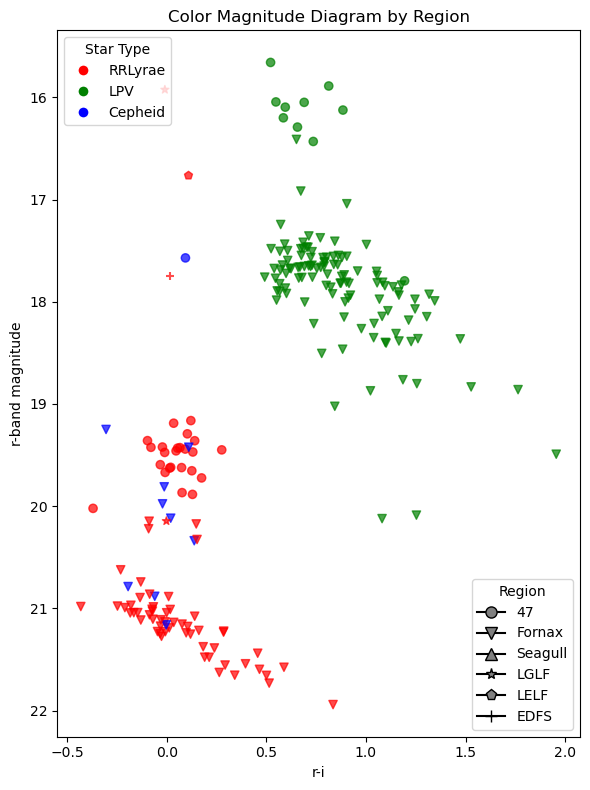

In [68]:
from matplotlib.lines import Line2D

plt.figure(figsize=(6,8))
for region, group in df_colmags.groupby('Region'):
    plt.scatter(
        group['FSODO_r_i'],
        group['weightedMag_r'], #'FSODO_rmag'
        c=group['color'],
        marker=symbol_map[region],
        label=region,
        alpha=0.7
    )

class_legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=cls, 
           markerfacecolor = col, markersize=8)
        for cls, col in color_map.items()
]

region_legend_elements = [
    Line2D([0], [0], marker=marker, color='k', label=region,
           markerfacecolor='gray', markersize=8)
        for region, marker in symbol_map.items()
]
    
# plt.scatter(x=df_colmags['r_i'], y=df_colmags['rmag'], c=df_colmags['color'], marker=11, cmap='Set1', alpha=0.7)
plt.xlabel('r-i')
plt.ylabel('r-band magnitude')
plt.title('Color Magnitude Diagram by Region')

legend1 = plt.legend(handles=class_legend_elements, title="Star Type", loc='upper left')
plt.gca().add_artist(legend1)

legend2 = plt.legend(handles=region_legend_elements, title="Region", loc='lower right')

plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()

Plot wesenheit color magnitude diagram (have wesenheit r-band magnitude vs wesenheit r-i color)

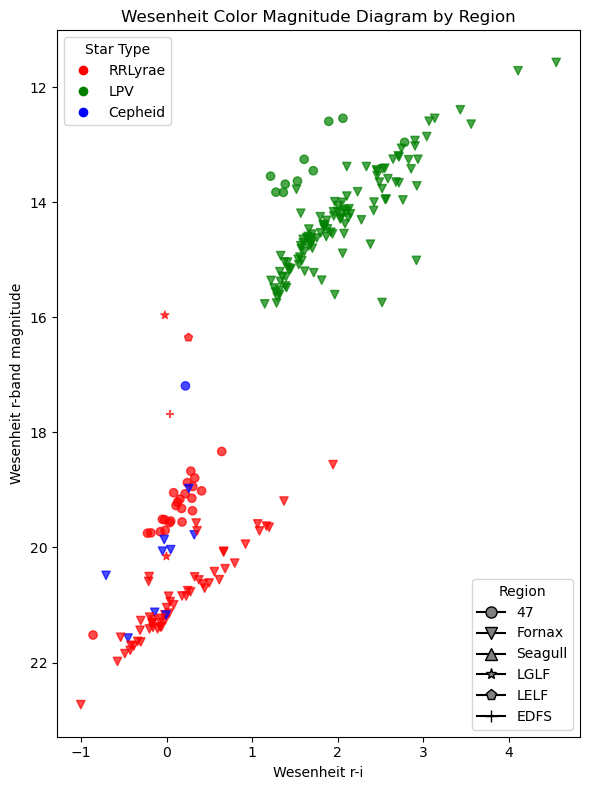

In [69]:
plt.figure(figsize=(6,8))
for region, group in df_colmags.groupby('Region'):
    plt.scatter(
        group['FSODO_W_r_i'], # wesenheit r-i color
        group['FSODO_W_mag_r_ri'], # wesenheit r-band magnitude
        c=group['color'],
        marker=symbol_map[region],
        label=region,
        alpha=0.7
    )

class_legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=cls, 
           markerfacecolor = col, markersize=8)
        for cls, col in color_map.items()
]

region_legend_elements = [
    Line2D([0], [0], marker=marker, color='k', label=region,
           markerfacecolor='gray', markersize=8)
        for region, marker in symbol_map.items()
]
    
# plt.scatter(x=df_colmags['r_i'], y=df_colmags['rmag'], c=df_colmags['color'], marker=11, cmap='Set1', alpha=0.7)
plt.xlabel('Wesenheit r-i')
plt.ylabel('Wesenheit r-band magnitude')
plt.title('Wesenheit Color Magnitude Diagram by Region')

legend1 = plt.legend(handles=class_legend_elements, title="Star Type", loc='upper left')
plt.gca().add_artist(legend1)

legend2 = plt.legend(handles=region_legend_elements, title="Region", loc='lower right')

plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()

In [70]:
fsodo_merged.to_csv('FSODO_v_stars.csv', index=False)

In [71]:
pd.set_option('display.max_rows', None)
fsodo_merged.isna().sum()

diaObjectId                  0
weightedMag_g                2
weightedMag_i                0
weightedMag_r                0
chi2_red_g                  23
chi2_red_i                   0
chi2_red_r                   0
fluxMagMin_g                 2
fluxMagMin_i                 0
fluxMagMin_r                 0
fluxMagMax_g                 2
fluxMagMax_i                 0
fluxMagMax_r                 0
fluxMagPerc05_g              2
fluxMagPerc05_i              0
fluxMagPerc05_r              0
fluxMagPerc95_g              2
fluxMagPerc95_i              0
fluxMagPerc95_r              0
fluxMagMedian_g              2
fluxMagMedian_i              0
fluxMagMedian_r              0
fluxMagMaxSlope_g           23
fluxMagMaxSlope_i            0
fluxMagMaxSlope_r            0
fluxMagSigma_g              23
fluxMagSigma_i               0
fluxMagSigma_r               0
fluxMagMAD_g                 2
fluxMagMAD_i                 0
fluxMagMAD_r                 0
fluxMagSkew_g               72
fluxMagS

### Test FSODO values using data visualization, PCA, and unsupervised learning

Subset of features we want to work with

In [72]:
features = ['fluxMagMaxSlope_r','fluxMagMaxSlope_i', 'fluxMagSkew_r','fluxMagSkew_i','FSODO_r_i', 'r_FSODO_amp', 
            'i_FSODO_amp', 'fluxMagSigma_r', 'fluxMagSigma_i', 'fluxMagMAD_r', 'fluxMagMAD_i', 'Region', 'Class']

In [73]:
df_subset = fsodo_merged[features]

In [74]:
df_subset.isna().sum()

fluxMagMaxSlope_r    0
fluxMagMaxSlope_i    0
fluxMagSkew_r        0
fluxMagSkew_i        0
FSODO_r_i            0
r_FSODO_amp          0
i_FSODO_amp          0
fluxMagSigma_r       0
fluxMagSigma_i       0
fluxMagMAD_r         0
fluxMagMAD_i         0
Region               0
Class                0
dtype: int64

In [75]:
df_subset.columns

Index(['fluxMagMaxSlope_r', 'fluxMagMaxSlope_i', 'fluxMagSkew_r',
       'fluxMagSkew_i', 'FSODO_r_i', 'r_FSODO_amp', 'i_FSODO_amp',
       'fluxMagSigma_r', 'fluxMagSigma_i', 'fluxMagMAD_r', 'fluxMagMAD_i',
       'Region', 'Class'],
      dtype='object')

In [76]:
df_subset.reset_index(inplace=True)

In [77]:
df_subset.columns

Index(['index', 'fluxMagMaxSlope_r', 'fluxMagMaxSlope_i', 'fluxMagSkew_r',
       'fluxMagSkew_i', 'FSODO_r_i', 'r_FSODO_amp', 'i_FSODO_amp',
       'fluxMagSigma_r', 'fluxMagSigma_i', 'fluxMagMAD_r', 'fluxMagMAD_i',
       'Region', 'Class'],
      dtype='object')

In [78]:
df_subset.drop(columns=['index'], inplace=True)

/tmp/ipykernel_24369/1704112502.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset.drop(columns=['index'], inplace=True)


In [79]:
df_subset.head()

,fluxMagMaxSlope_r,fluxMagMaxSlope_i,fluxMagSkew_r,fluxMagSkew_i,FSODO_r_i,r_FSODO_amp,i_FSODO_amp,fluxMagSigma_r,fluxMagSigma_i,fluxMagMAD_r,fluxMagMAD_i,Region,Class
0,155.239650,4.330673,-1.019177,-1.381779,0.034477,0.771063,0.348623,0.284631,0.164123,0.153692,0.130451,47,RRLyrae
1,34.191454,32.035882,-0.873031,2.208658,0.275890,0.665399,0.521818,0.266363,0.276490,0.133669,0.008104,47,RRLyrae
2,480.613511,12.025185,4.418885,-0.219254,0.813143,0.153897,0.027454,0.126602,0.011975,0.013977,0.009800,47,LPV
3,140.128232,57.673402,-0.061211,0.609103,0.065931,0.457980,0.307258,0.166437,0.132546,0.167230,0.078936,47,RRLyrae
4,56.722660,90.195910,0.272660,-1.072000,-0.079535,0.470558,0.306599,0.178805,0.129163,0.139402,0.041407,47,RRLyrae


**Visualize the data**

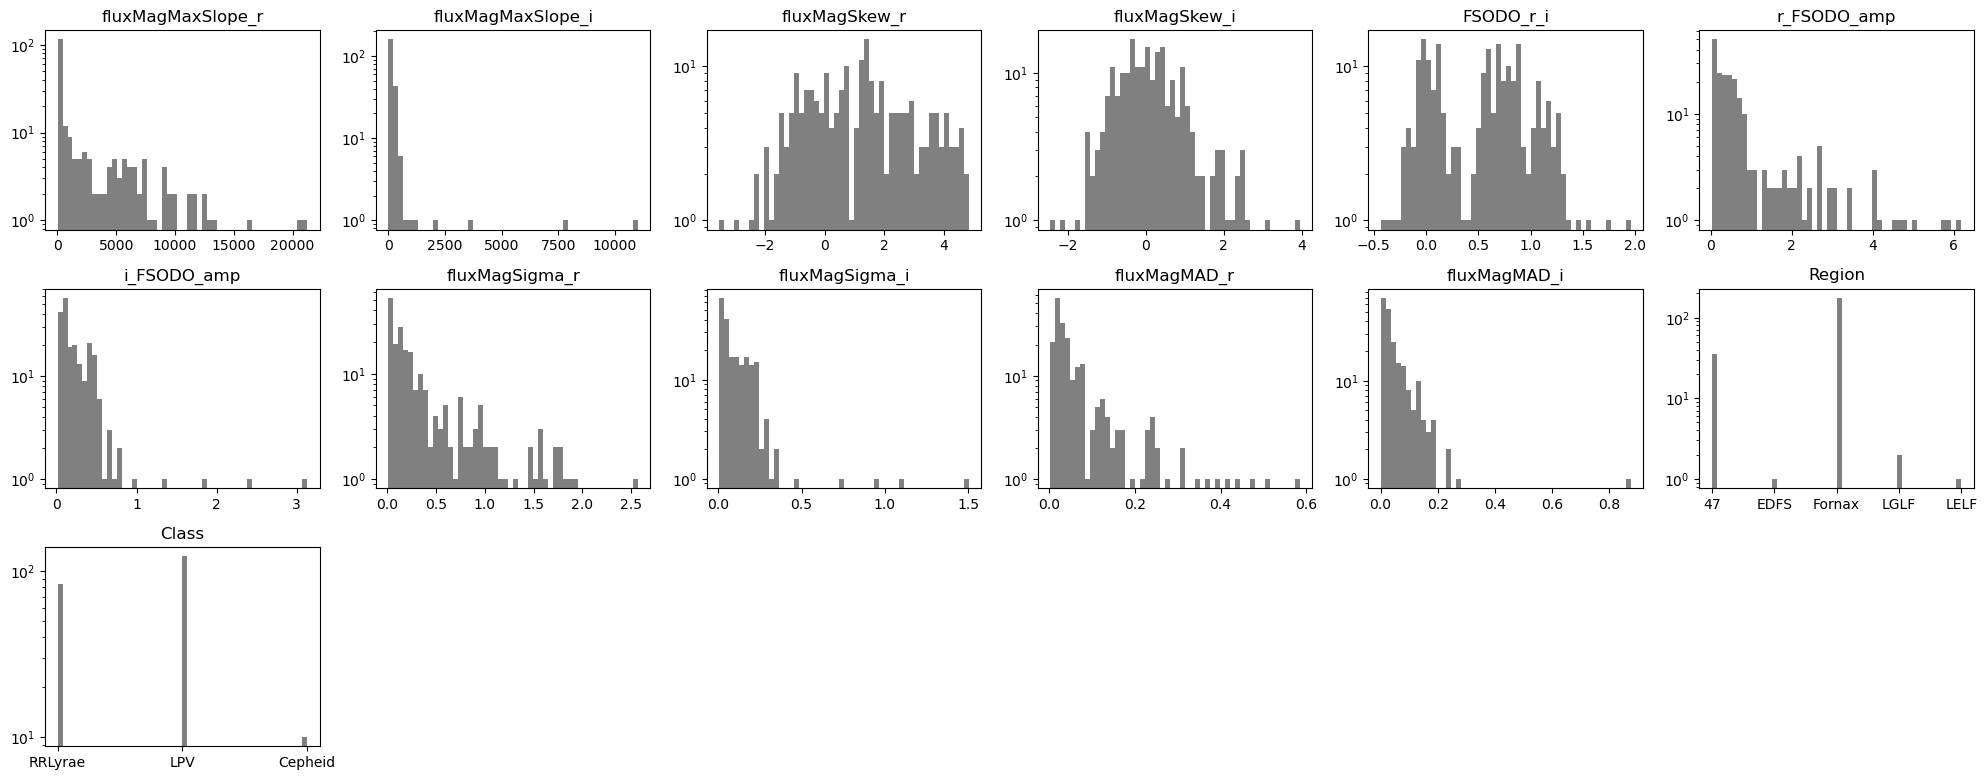

In [80]:
# now that we have all of our helpful features, we can visualize all of them in multiple histograms to see outliers and gain some intuition
fig = plt.figure(0, [20,18])

for k, feat in enumerate(features):
    ax = fig.add_subplot(7, 6, k+1)
    ax.hist(df_subset[feat], bins=50, log=True, color='grey')
    ax.set_title(feat)
    
plt.tight_layout()
plt.show()


Standardize the features using RobustScaler/StandardScaler and visualize after as well

In [81]:
from sklearn.preprocessing import RobustScaler

In [82]:
# transform each feature to have a mean of 0 and a standard deviation of 1
X = df_subset.copy()
scaler = RobustScaler()

X_scaled = scaler.fit_transform(X.drop(columns=['Region', 'Class'])) # drop region since it is categorical

In [83]:
pd.reset_option('display.max_rows')

In [84]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns.drop(['Region', 'Class']))

X_scaled_df

,fluxMagMaxSlope_r,fluxMagMaxSlope_i,fluxMagSkew_r,fluxMagSkew_i,FSODO_r_i,r_FSODO_amp,i_FSODO_amp,fluxMagSigma_r,fluxMagSigma_i,fluxMagMAD_r,fluxMagMAD_i
0,-0.047409,-0.730298,-0.806419,-1.265196,-0.706139,0.461525,0.599560,0.239902,0.710513,2.007659,1.881532
1,-0.079155,-0.565953,-0.753312,1.975939,-0.401169,0.308834,1.168903,0.199946,1.525769,1.664770,-0.417758
2,0.037923,-0.684655,1.169670,-0.215769,0.277526,-0.430318,-0.456219,-0.105735,-0.393354,-0.384894,-0.385891
3,-0.051373,-0.413873,-0.458312,0.531999,-0.666404,0.009100,0.463580,-0.018609,0.481419,2.239481,0.913389
4,-0.073246,-0.220952,-0.336990,-0.985555,-0.850166,0.027277,0.461413,0.008442,0.456872,1.762953,0.208099
...,...,...,...,...,...,...,...,...,...,...,...
211,-0.061576,0.213305,0.054053,-0.336494,-0.787049,0.090133,0.934147,-0.012425,1.094036,0.150198,0.715022
212,-0.077439,-0.539743,-0.414613,0.444377,-0.034333,-0.608759,-0.477927,-0.359788,-0.419934,-0.520083,-0.465163
213,-0.069292,-0.315772,-0.472492,0.331278,-0.752235,0.225734,0.911480,0.078706,0.910444,2.141216,1.773924
214,-0.035687,-0.649541,-0.620730,-0.270877,-0.761851,-0.206745,0.307606,-0.137588,0.392877,0.595256,0.131175


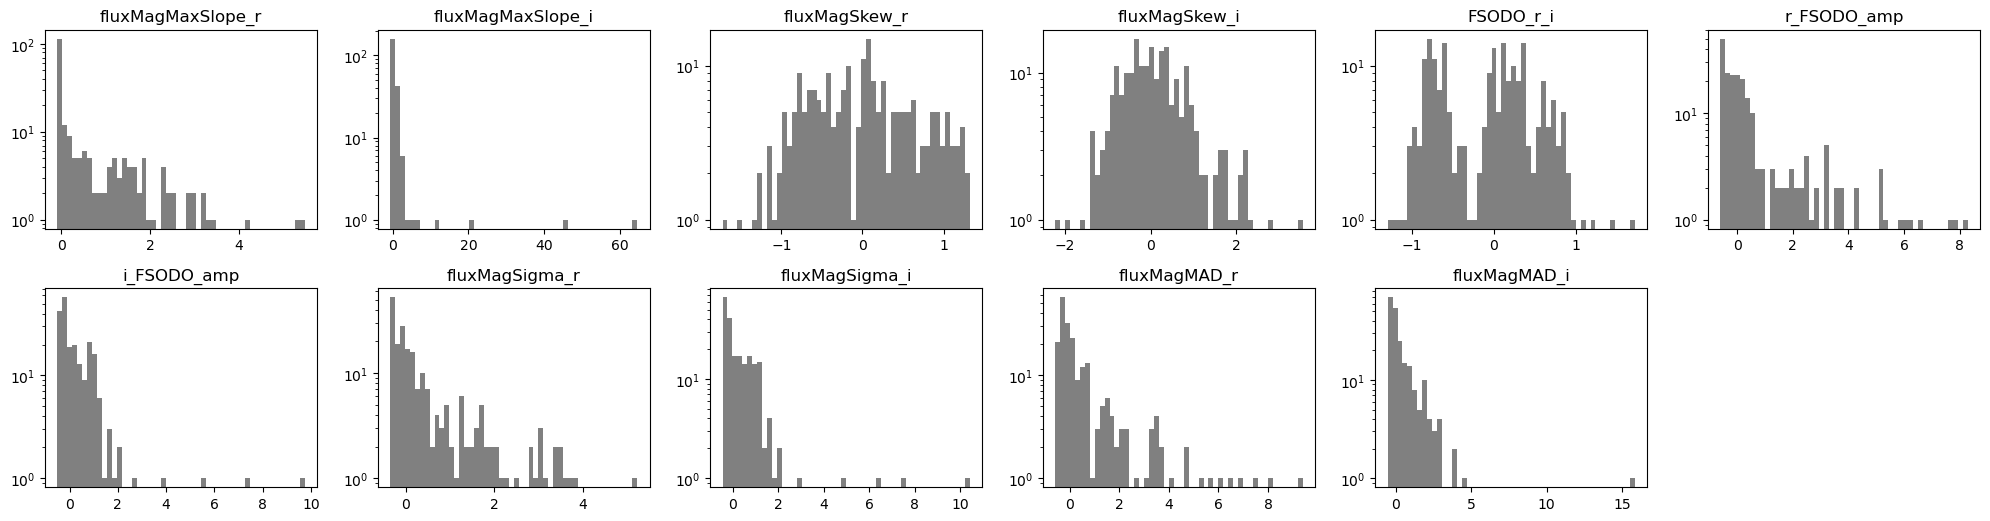

In [85]:
fig = plt.figure(0, [20,18])
features_scaled = X_scaled_df.columns.tolist()

for k, feat in enumerate(features_scaled):
    ax = fig.add_subplot(7, 6, k+1)
    ax.hist(X_scaled_df[feat], bins=50, log=True, color='grey')
    ax.set_title(feat)
    
plt.tight_layout()
plt.show()

It looks like the features with the most outliers are the mag max slope as well as MAD / Sigma. The amplitude outliers are sort of expeced and something that we are interested in keeping, as opposed to the variability columns and those impacted by the significantly higher brightness / flux that LPVs possess.

### Implement Anomaly / Outlier Detection and Removal

Try implementing unsupervised ML for anomaly detection

**Still have to try removing outliers in certain columns (haven't got to just yet)**

In [86]:
def handle_outliers(df, feature, factor=1.5, dropUpper=True, dropLower=True):
    outlier_mask = pd.Series(False, index=df.index)
    
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR

    if(dropUpper and dropLower):
        outlier_mask[(df[feature] < lower) | (df[feature] > upper)] = True
    elif dropUpper:
        outlier_mask[df[feature] > upper] = True
    elif dropLower:
        outlier_mask[df[feature] < lower] = True

    return outlier_mask

In [87]:
outlier_indices1 = handle_outliers(X_scaled_df, 'fluxMagMaxSlope_r', factor=3.0, dropLower=False)
outlier_indices2 = handle_outliers(X_scaled_df, 'fluxMagMaxSlope_i', factor=3.0, dropLower=False)
# outlier_indices3 = handle_outliers(X_scaled_df, 'r_psfFluxStetsonJ', factor=3.0, dropLower=False)
# outlier_indices4 = handle_outliers(X_scaled_df, 'i_psfFluxStetsonJ', factor=3.0, dropLower=False)
# outlier_indices5 = handle_outliers(X_scaled_df, 'chi2_red_r', factor=3.0, dropLower=False)
# outlier_indices6 = handle_outliers(X_scaled_df, 'chi2_red_i', factor=3.0, dropLower=False)

outlier_indices_both = outlier_indices1 | outlier_indices2 
# | outlier_indices3 | outlier_indices4 | outlier_indices5 | outlier_indices6

In [88]:
outlier_indices_both.value_counts()

False    206
True      10
Name: count, dtype: int64

In [89]:
X_clean = X_scaled_df[~outlier_indices_both]

In [90]:
X_clean

,fluxMagMaxSlope_r,fluxMagMaxSlope_i,fluxMagSkew_r,fluxMagSkew_i,FSODO_r_i,r_FSODO_amp,i_FSODO_amp,fluxMagSigma_r,fluxMagSigma_i,fluxMagMAD_r,fluxMagMAD_i
0,-0.047409,-0.730298,-0.806419,-1.265196,-0.706139,0.461525,0.599560,0.239902,0.710513,2.007659,1.881532
1,-0.079155,-0.565953,-0.753312,1.975939,-0.401169,0.308834,1.168903,0.199946,1.525769,1.664770,-0.417758
2,0.037923,-0.684655,1.169670,-0.215769,0.277526,-0.430318,-0.456219,-0.105735,-0.393354,-0.384894,-0.385891
3,-0.051373,-0.413873,-0.458312,0.531999,-0.666404,0.009100,0.463580,-0.018609,0.481419,2.239481,0.913389
4,-0.073246,-0.220952,-0.336990,-0.985555,-0.850166,0.027277,0.461413,0.008442,0.456872,1.762953,0.208099
...,...,...,...,...,...,...,...,...,...,...,...
211,-0.061576,0.213305,0.054053,-0.336494,-0.787049,0.090133,0.934147,-0.012425,1.094036,0.150198,0.715022
212,-0.077439,-0.539743,-0.414613,0.444377,-0.034333,-0.608759,-0.477927,-0.359788,-0.419934,-0.520083,-0.465163
213,-0.069292,-0.315772,-0.472492,0.331278,-0.752235,0.225734,0.911480,0.078706,0.910444,2.141216,1.773924
214,-0.035687,-0.649541,-0.620730,-0.270877,-0.761851,-0.206745,0.307606,-0.137588,0.392877,0.595256,0.131175


**Visualize the data after outlier cleaning**

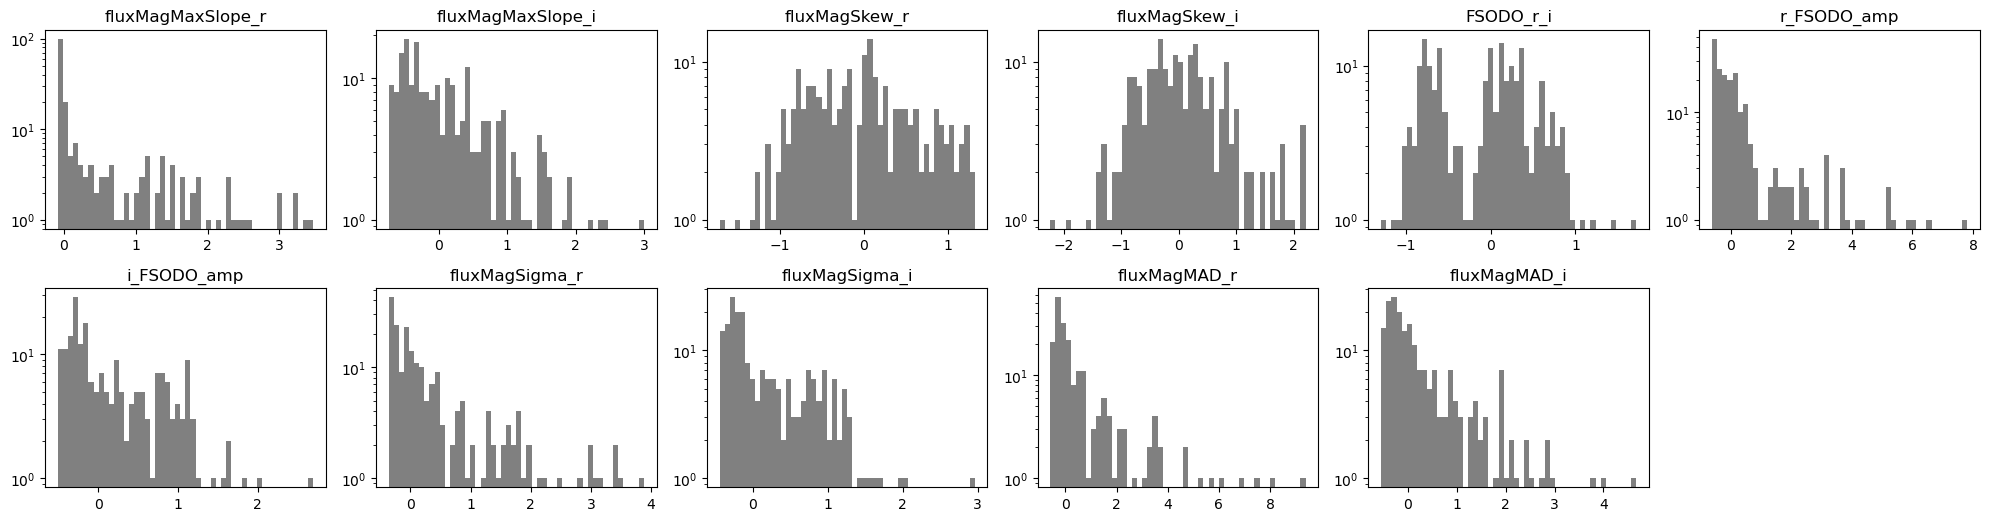

In [91]:
fig = plt.figure(0, [20,18])

for k, feat in enumerate(features_scaled):
    ax = fig.add_subplot(7, 6, k+1)
    ax.hist(X_clean[feat], bins=50, log=True, color='grey')
    ax.set_title(feat)
    
plt.tight_layout()
plt.show()

In [92]:
region_clean = df_subset.loc[X_clean.index, 'Region']
labels_clean = df_subset.loc[X_clean.index, 'Class']

In [93]:
region_clean.value_counts()

Region
Fornax    171
47         31
LGLF        2
EDFS        1
LELF        1
Name: count, dtype: int64

In [94]:
labels_clean.value_counts()

Class
LPV        118
RRLyrae     79
Cepheid      9
Name: count, dtype: int64

**Apply PCA**

In [95]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clean)

print(X_pca[:2])

[[0.66521082 2.05072522]
 [0.15057526 0.62028816]]


In [96]:
print("Explained variance:", pca.explained_variance_ratio_)
print("Cumulative:", np.cumsum(pca.explained_variance_ratio_))

Explained variance: [0.57242672 0.15547264]
Cumulative: [0.57242672 0.72789937]


In [97]:
le = LabelEncoder()
y_encoded = le.fit_transform(labels_clean)

classes = le.classes_
classes

array(['Cepheid', 'LPV', 'RRLyrae'], dtype=object)

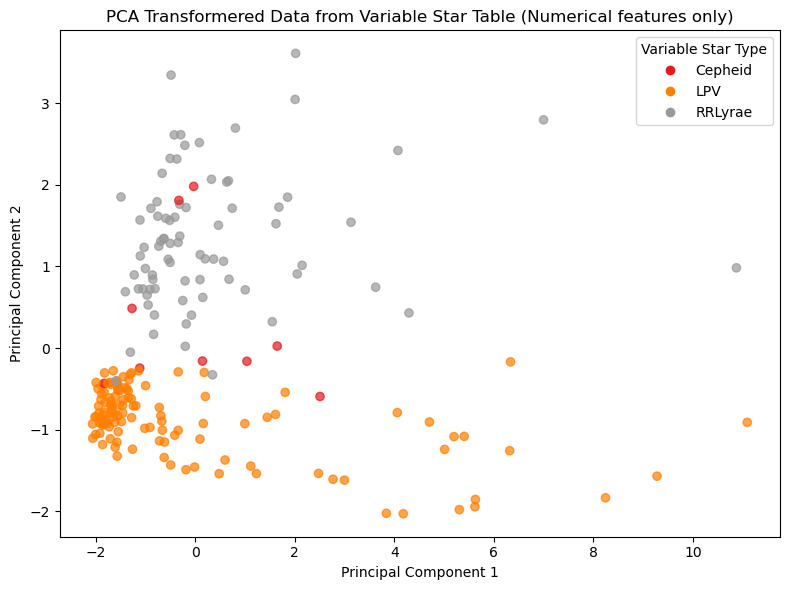

In [98]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_encoded, cmap='Set1', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Transformered Data from Variable Star Table (Numerical features only)')

handles = [
    plt.Line2D([], [], marker='o', linestyle='', color=scatter.cmap(scatter.norm(i)), label=label)
    for i, label in enumerate(classes)
]

plt.legend(handles=handles, title='Variable Star Type')

plt.tight_layout()
plt.show()

In [99]:
# check how much each feature is contributing to the variance / pca analysis
print(pca.components_) # n_components * n_features (2 x 12)

components_abs = np.abs(pca.components_.T) # now shape is n_features * n_components (can see how much each feature contributes to each PC)
components_norm = components_abs / components_abs.sum(axis=0) # normalize features column wise, so each value shows fractional contributions of feature to that component
# each column should sum up to 1

df_contrib = pd.DataFrame(components_norm, index=X_clean.columns, columns=['PC 1', 'PC 2'])
df_contrib

[[ 0.28070932  0.18641575  0.10197117 -0.02726125  0.05326881  0.59578347
   0.06948083  0.34955958  0.05959844  0.61302861  0.10554203]
 [-0.19670261  0.03581603 -0.12881416 -0.12774288 -0.37214011 -0.10238488
   0.41273058 -0.09916549  0.42171628  0.08490586  0.64258002]]


,PC 1,PC 2
fluxMagMaxSlope_r,0.114921,0.074943
fluxMagMaxSlope_i,0.076318,0.013646
fluxMagSkew_r,0.041747,0.049078
fluxMagSkew_i,0.011161,0.048670
FSODO_r_i,0.021808,0.141784
r_FSODO_amp,0.243912,0.039008
i_FSODO_amp,0.028445,0.157249
fluxMagSigma_r,0.143109,0.037782
fluxMagSigma_i,0.024399,0.160672
fluxMagMAD_r,0.250972,0.032349


### Apply Unsupervised Learning to this Dataset

In [100]:
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42) # start with two since our dominant classes are 
gmm.fit(X_clean)

print("Means:\n", gmm.means_)
print("Covariances:\n", gmm.covariances_)
print("Weights:\n", gmm.weights_)

Means:
 [[ 2.15135454e-02 -1.33055982e-01 -3.53468413e-01  7.24872912e-02
  -2.23134346e-01 -1.67920382e-01  2.05899444e-01 -9.29946282e-02
   2.60322257e-01  9.81410495e-02  3.56733515e-01]
 [ 1.46582626e+00  7.66925096e-01  6.56030904e-01 -8.59976426e-05
   2.08645024e-01  1.92385940e+00  1.64560114e-01  1.39501949e+00
   1.54269631e-01  1.71480423e+00  3.35416830e-01]]
Covariances:
 [[[ 4.74300598e-02  3.33440728e-02  2.58491261e-02  2.34875920e-03
   -3.17870638e-03  2.59876549e-02  3.52548760e-02  2.85785397e-02
    3.51681842e-02  2.87032276e-02  7.53769866e-02]
  [ 3.33440728e-02  2.14269066e-01  5.28163339e-02 -2.34579098e-02
   -7.43257447e-02  5.61412744e-02  1.08773588e-01  3.37772409e-02
    1.04222386e-01 -8.00006409e-03  1.31737673e-01]
  [ 2.58491261e-02  5.28163339e-02  2.48573770e-01 -9.34494851e-02
   -1.08402697e-02  5.32863613e-03  7.05272542e-03  1.78663864e-02
    3.96624002e-03 -1.57397218e-02  5.81502281e-02]
  [ 2.34875920e-03 -2.34579098e-02 -9.34494851e-02  6

In [101]:
# gmm labels
gmm_labels = gmm.predict(X_clean)

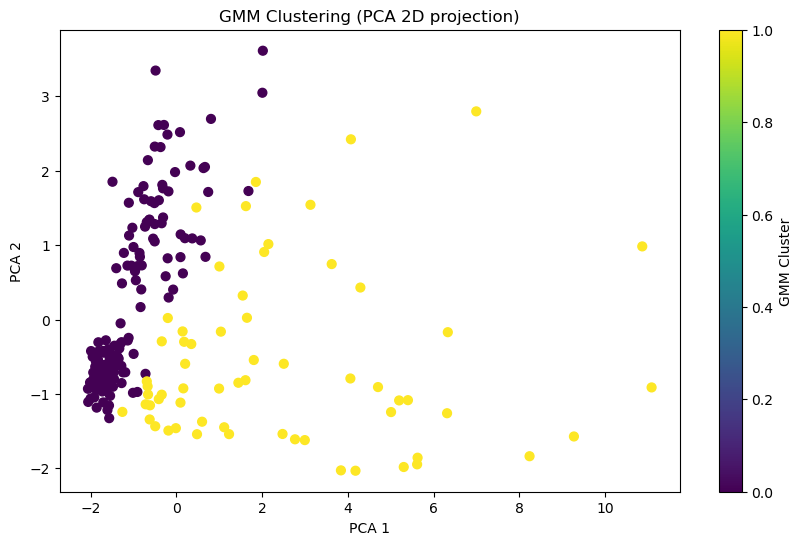

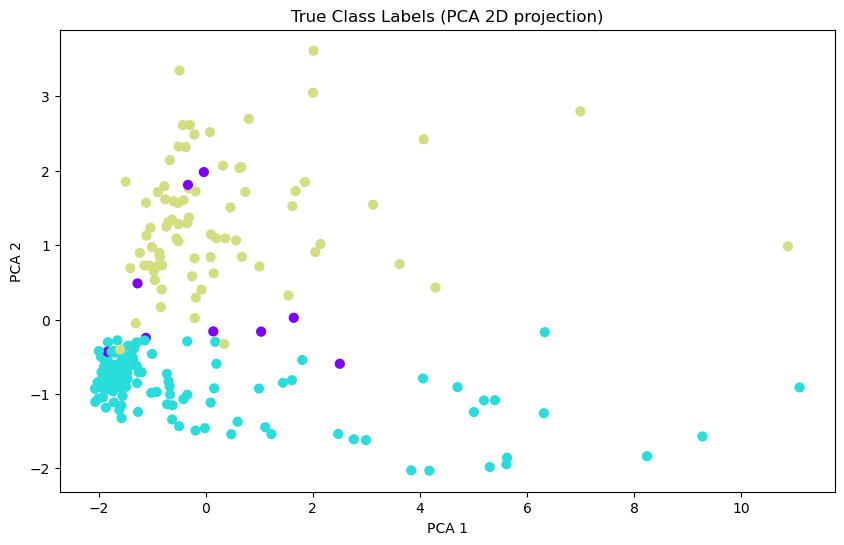

In [104]:
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap='viridis', s=40)
plt.title('GMM Clustering (PCA 2D projection)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(label='GMM Cluster')
plt.show()

plt.figure(figsize=(10, 6))
unique_labels = np.unique(labels_clean)
label_colors = {label: cm.rainbow(i / len(unique_labels)) for i, label in enumerate(unique_labels)}
colors = [label_colors[label] for label in labels_clean]

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, s=40)
plt.title('True Class Labels (PCA 2D projection)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

Conclusion is using magnitude scales didn't entirely help and we would prefer percentages of variation using fluxes opposed to magnitudes (sigma norm / MAD norm)